<a href="https://colab.research.google.com/github/Yvonneamg/Modelling-the-epidemiologic-evolution-of-Diabetes-Mellitus-Integrating-Physiological-Agent-models/blob/main/2ndExpFinalHybridModeltodate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Load the required libraries**

In [ ]:
# load the required libraries
!pip install jax jaxlib diffrax numpyro pyreadstat scipy matplotlib pandas
import scipy
import jax # For high performance numerical computing and automatic differentiation
import jax.numpy as jnp
import time
import scipy.stats
import jax.random as random
from jax import debug
from scipy import optimize
from scipy.stats import lognorm
from scipy.stats import multivariate_normal
from sklearn.metrics import roc_curve, auc
import pyreadstat
import pandas as pd # For data handling
import numpy as np # For data handling
from jax import jit, vmap
from jax.experimental.ode import odeint
from scipy.optimize import differential_evolution
from jax.scipy.special import logsumexp
import diffrax # For solving ODES
import math
from functools import partial
import matplotlib.pyplot as plt # For visualization
import matplotlib as mpl
from collections import defaultdict
import gc
import os
from datetime import datetime
import pickle
import numpyro # For probablistic modeling to be implemented later
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO, init_to_median
from tqdm import tqdm
import optax
print("Setup complete!")

Setup complete!


#**Global Figure Saver**

In [ ]:
# ============================================================================
# GLOBAL FIGURE SAVER
# ============================================================================

# Folder to store plots
PLOT_OUTPUT_DIR = "diabetes_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

def save_figure(fig, name_prefix):
    """
    Save a matplotlib figure safely with timestamp.
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{name_prefix}_{timestamp}.png"

    filepath = os.path.join(PLOT_OUTPUT_DIR, filename)

    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    #plt.close(fig)

    print(f"Saved: {filename}")
    #return filepath

# **Reproduce De Gaetano Physiological Model.**

[5.0e+00 1.0e+03 3.5e+01 1.0e-03 1.0e-02 1.8e+01]
Simulation completed
Base:3.1620097160339355
Base:0.002124786376953125
Base:0.0023157596588134766
Base:0.002465486526489258
Saved: physiological_model_validation_20260514_011959.png


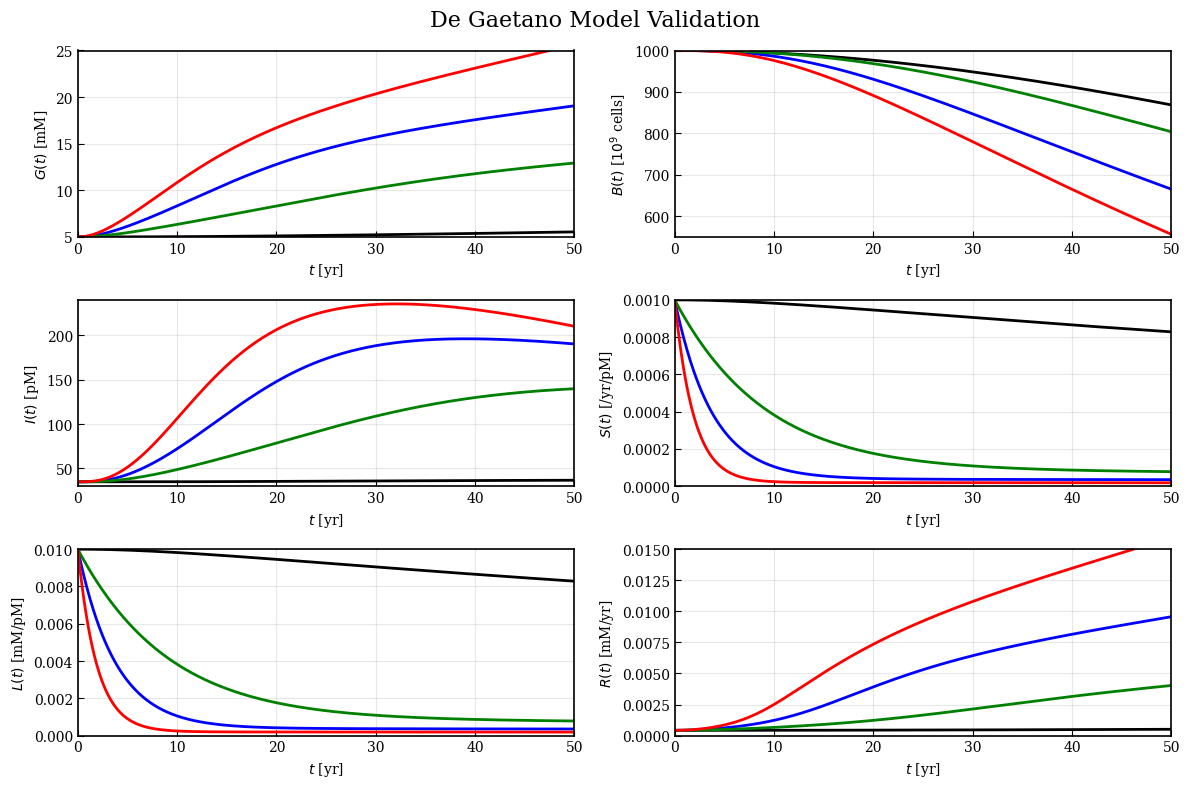

In [ ]:
# =============================================================================
# PART 1: DE GAETANO PHYSIOLOGICAL MODEL
# =============================================================================

# Base parameters (Table 2)
params_base = {
    't0': 0, 'tend': 50, 't_delta': 0.1,
    'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0,
    'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144,
    'k_max_G': 1.00948, 'G_0': 5.0,
    'lambda_BA': 0.005, 'k_OB_G': 0.005, 'k_B': 25.0, 'B0_N': 1000.0,
    'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0,
    'k_S': 0.0001, 'k_SY': 1e-09, 'k_OS': 0.1, 'k_OSF': 1e-05, 'k_OSA': 0.0005, 'S_0': 0.001,
    'k_L': 0.001, 'k_LY': 2e-09, 'k_OL': 0.1, 'k_OLF': 1e-05, 'k_OLA': 0.0005, 'L_0': 0.01,
    's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144,
    'F': 0.0, 'Y': 0.0, 'A0': 18.0
}


# Case parameters (Table 3)
params_cases = {}

for case in ['Black', 'Blue', 'Green', 'Red']:
    params_cases[case] = params_base.copy()

params_cases['Black'].update({
    'k_OB_G': 0.005, 'k_OS': 0.1, 'k_OL': 0.1,
    'k_B': 25.0, 'k_S': 0.0001, 'k_L': 0.001,
    'F': 0.0, 'k_OSF': 1e-05, 'k_OLF': 1e-5
})

params_cases['Blue'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0005, 'k_OLF': 0.0005
})

params_cases['Green'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0002, 'k_OLF': 0.0002
})

params_cases['Red'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.001, 'k_OLF': 0.001
})

# Initial conditions (y0: [G, B, I, S, L, A]; B0=1000 Mc from Table 2)
A0=params_base['A0']
y0_base = jnp.array([params_base['G_0'], params_base['B_0'], params_base['I_0'], params_base['S_0'], params_base['L_0'],params_base['A0'] ])
print(y0_base)

# ODE RHS

def ode_rhs(t, y, params): #function ode_rhs that calculates how fast each body variable (like glucose or insulin) is changing at a specific moment t. It's the "rules" for how the system evolves, based on current states and settings.
    G, B, I, S, L, A = y #the array of state variables at time t
    F = params['F']
    Y = params['Y']

    # Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = params['k_max_G'] * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = params['k_B'] * (jnp.exp(-params['lambda_BA'] * (A - A0))) - (params['k_OB_G'] * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(params['k_OI'] * I) + ((B / params['B0_N']) * params['k_max_I'] * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = params['k_S'] - (params['k_OS'] * S) + (params['k_SY'] * Y) - (params['k_OSF'] * F * S) - (params['k_OSA'] * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = params['k_L'] - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (params['k_OLF'] * F * L) - (params['k_OLA'] * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])


#def ode_rhs_scan(y, t_span, opt_params, params, dt, y0): # Only introducing clipping and safe exponents to avoid Nans

    # Clip array of state variables at time t
    #G = jnp.clip(y[0], 1e-6, 1e3)
    #B = jnp.clip(y[1], 1e-6, 1e6)
    #I = jnp.clip(y[2], 1e-6, 1e4)
    #S = jnp.clip(y[3], 1e-6, 1e2)
    #L = jnp.clip(y[4], 1e-6, 1e2)
    #A = y[5]

    # Clip array of state variables at time t
    #G0 = jnp.clip(y0[0], 1e-6, 1e3)
    #B0 = jnp.clip(y0[1], 1e-6, 1e6)
    #I0 = jnp.clip(y0[2], 1e-6, 1e4)
    #S0 = jnp.clip(y0[3], 1e-6, 1e2)
    #L0 = jnp.clip(y0[4], 1e-6, 1e2)
    #A0 = y0[5]

    #lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    #F = params['F']
    #Y = params['Y']

    # introduce safe exponents
    #safe_exp_input_0 = jnp.clip(L0 * I0 * G0, -50, 50)
    #safe_exp_input = -jnp.clip(L * I * G, -50, 50)

    # kidney function
    #discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2)
    #R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR']))

    #discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    #R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))


    #k_max_G = jnp.exp(safe_exp_input_0) * (S0 * I0 * G0 + R0)

    #k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))

    #k_B = k_OB_G * G0 * B0
    #k_L = params['k_OL'] * L0 + k_OLF*F*L0
    #k_S = params['k_OS'] * S0 + k_OSF*F*S0

    # Safe dynamics
    #dGdt = k_max_G * jnp.exp(safe_exp_input) - (S * I * G) - R

    #dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    #hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG']))
    #dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill)

    #dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    #dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    #dAdt = 1.0

    #next_state = y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

    #next_state = jnp.nan_to_num(next_state, nan=0.0, posinf=1e6, neginf=-1e6) # ensure simulation never breaks

    #return next_state, next_state


def ode_rhs_scan(y, t_span, opt_params , params, dt, y0):
    G, B, I, S, L, A = y #the array of state variables at time t
    G0, B0, I0, S0, L0, A0 = y0 #the array of state variables at time t
    lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    F = params['F'] # to be discussed
    Y = params['Y'] # to be discussed

    #Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    #k_max_G = (jnp.exp(L0 * I0 * G0)) * (S0 * I0 * G0 + R0)
    #k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))
    #k_B = k_OB_G * G0 * B0
    #k_L = params['k_OL'] * L0 + k_OLF*F*L0
    #k_S = params['k_OS'] * S0 + k_OSF*F*S0

    #k_max_G = (jnp.exp(params['L0_N'] * params['I0_N'] * params['G0_N'])) * (params['S0_N'] * params['I0_N'] * params['G0_N'] + params['R0_N'])
    #k_max_I = (params['k_OI'] * params['I0_N']) / ((params['G0_N'] ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + params['G0_N'] ** params['gamma_IG']))
    #k_B = params['k_OB_G'] *  params['G0_N'] *  params['B0_N']
    #k_L = params['k_OL'] *  params['L0_N']
    #k_S = params['k_OS'] *  params['S0_N']

    k_max_G = params['k_max_G']
    k_max_I = params['k_max_I']
    k_B = params['k_B']
    k_L = params['k_L']
    k_S = params['k_S']

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = k_max_G * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0
    #next_state = jax.nn.softplus((y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt]))*100.0)/100.0
    #return next_state, next_state
    next_state = y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])
    return next_state, next_state

# -----------------------------------------------------------------------------
# Euler solver
# -----------------------------------------------------------------------------
@jit
def solve_ode(params, t_span, y0):
    """Solve ODE with Diffrax"""
    def rhs(t, y, args): return ode_rhs(t, y, args) #A wrapper that calls the change-calculating function above.
    term = diffrax.ODETerm(rhs)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(term, solver, t0=t_span[0], t1=t_span[-1], dt0=0.1, y0=y0,args=params, saveat=diffrax.SaveAt(ts=t_span)) # Runs the solver: starts at time 0, goes to the end time, steps by 0.1 units, uses initial values y0, passes settings (params), and saves results at specific times in t_span.
    return sol.ys

t_span = jnp.linspace(0, 50, 1000)


print("Simulation completed")
#print("Solution shape:", sol.shape)

# PHYSIOLOGICAL MODEL VALIDATION PLOT

# R computation
def compute_R(G, params):
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))
    return R

# Time span


# Figure and colors
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
fig.suptitle("De Gaetano Model Validation", fontsize=16, y=0.98)

colors = {
    'Black': 'black',
    'Blue': 'blue',
    'Green': 'green',
    'Red': 'red'
}

for case, color in colors.items():

    # Get parameters
    params = params_cases[case]

    y0 = jnp.array([
        params['G_0'],
        params['B_0'],
        params['I_0'],
        params['S_0'],
        params['L_0'],
        params['A0']
    ])

    # Solve model
    start_t = time.time()
    sol = solve_ode(params, t_span, y0)
    print("Base:"+str(time.time()-start_t))

    sol = np.array(sol)

    # Create age axis
    age = np.linspace(0, 50, len(sol))

    # Plot states
    axes[0,0].plot(age, sol[:,0], color=color, linewidth=2, label=case)
    axes[0,1].plot(age, sol[:,1], color=color, linewidth=2, label=case)
    axes[1,0].plot(age, sol[:,2], color=color, linewidth=2, label=case)
    axes[1,1].plot(age, sol[:,3], color=color, linewidth=2, label=case)
    axes[2,0].plot(age, sol[:,4], color=color, linewidth=2, label=case)

     # Compute R from G
    R_values = compute_R(sol[:,0], params)
    axes[2,1].plot(age, R_values, color=color, linewidth=2.0)  # R(t)


# =============================================================================
# AXIS LABELS
# =============================================================================

axes[0,0].set_ylabel(r"$G(t)$ [mM]")
axes[0,0].set_xlabel(r"$t$ [yr]")
axes[0,0].set_xlim(0,50)
axes[0,0].set_ylim(5,25)

axes[0,1].set_ylabel(r"$B(t)$ [$10^9$ cells]")
axes[0,1].set_xlabel(r"$t$ [yr]")
axes[0,1].set_xlim(0,50)
axes[0,1].set_ylim(550,1000)

axes[1,0].set_ylabel(r"$I(t)$ [pM]")
axes[1,0].set_xlabel(r"$t$ [yr]")
axes[1,0].set_xlim(0,50)
axes[1,0].set_ylim(30,240)

axes[1,1].set_ylabel(r"$S(t)$ [/yr/pM]")
axes[1,1].set_xlabel(r"$t$ [yr]")
axes[1,1].set_xlim(0,50)
axes[1,1].set_ylim(0.0000,0.0010)

axes[2,0].set_ylabel(r"$L(t)$ [mM/pM]")
axes[2,0].set_xlabel(r"$t$ [yr]")
axes[2,0].set_xlim(0,50)
axes[2,0].set_ylim(0.000,0.010)

axes[2,1].set_ylabel(r"$R(t)$ [mM/yr]")
axes[2,1].set_xlabel(r"$t$ [yr]")
axes[2,1].set_xlim(0,50)
axes[2,1].set_ylim(0.000,0.015)


# Grid
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

# Layout
plt.tight_layout()

# Save figure using global saver
save_figure(fig, "physiological_model_validation")

# Show plot
plt.show()

##**Renal Glucose Elimination**

Saved: Renal glucose elimination_20260514_012002.png


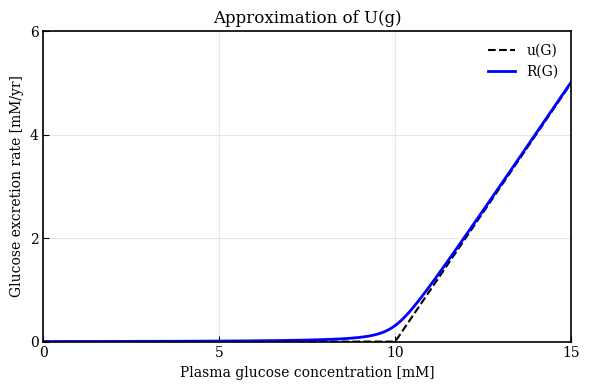

In [ ]:
# The term  𝑅(𝐺(𝑡)) represents the average decrement of glucose concentration due to renal glucose elimination and to possible therapy with SGLT-2 inhibitors.
# Construction of equation 8
s_GR = 1.0  # mM/yr per mM (scale for linear elimination)
rho_GR = 0.01 # mM (smoothing factor)
G_R = 10.0  # mM (renal threshold)

# Glucose range (x-axis: 0 to 15 mM)
G = np.linspace(0, 15, 1000)

# Exact step function u(G) from Eq. (9)
u_G = np.where(G < G_R, 0, (s_GR * (G - G_R)))  # Piecewise: 0 below threshold, linear above

# Smooth approximation R(G) from Eq. (8)
discriminant = (4 * rho_GR * G) + ((G - G_R - rho_GR)**2)
R_G = (s_GR / 2) * (np.sqrt(discriminant) + (G - G_R - rho_GR))

# Plot dashed for u(G), solid blue for R(G)
plt.figure(figsize=(6, 4))
plt.plot(G, u_G, 'k--', linewidth=1.5, label='u(G)')  # Dashed black
plt.plot(G, R_G, 'b-', linewidth=2, label='R(G)')     # Solid blue
plt.xlabel('Plasma glucose concentration [mM]')
plt.ylabel('Glucose excretion rate [mM/yr]')
plt.xlim(0, 15)
plt.ylim(0, 6)
plt.xticks(np.arange(0, 16, 5))  # x-axis ticks: 0, 5, 10, 15
plt.yticks(np.arange(0, 7, 2))   # y-axis ticks: 0, 2, 4, 6
plt.grid(True, alpha=0.3)  # Light grid for readability
plt.legend()
plt.title('Approximation of U(g)')
plt.tight_layout()
save_figure(fig,"Renal glucose elimination")
plt.show()

# The smooth R(G) effectively approximates the biological renal threshold mechanism (where kidneys excrete excess glucose only above ~10 mM), no elimination in normoglycemia (G<10 mM), linear spillover in hyperglycemia

## **Simulation of impact of dietary changes**

Saved: Impact of dietary scenarios on model trajectories_20260514_012012.png


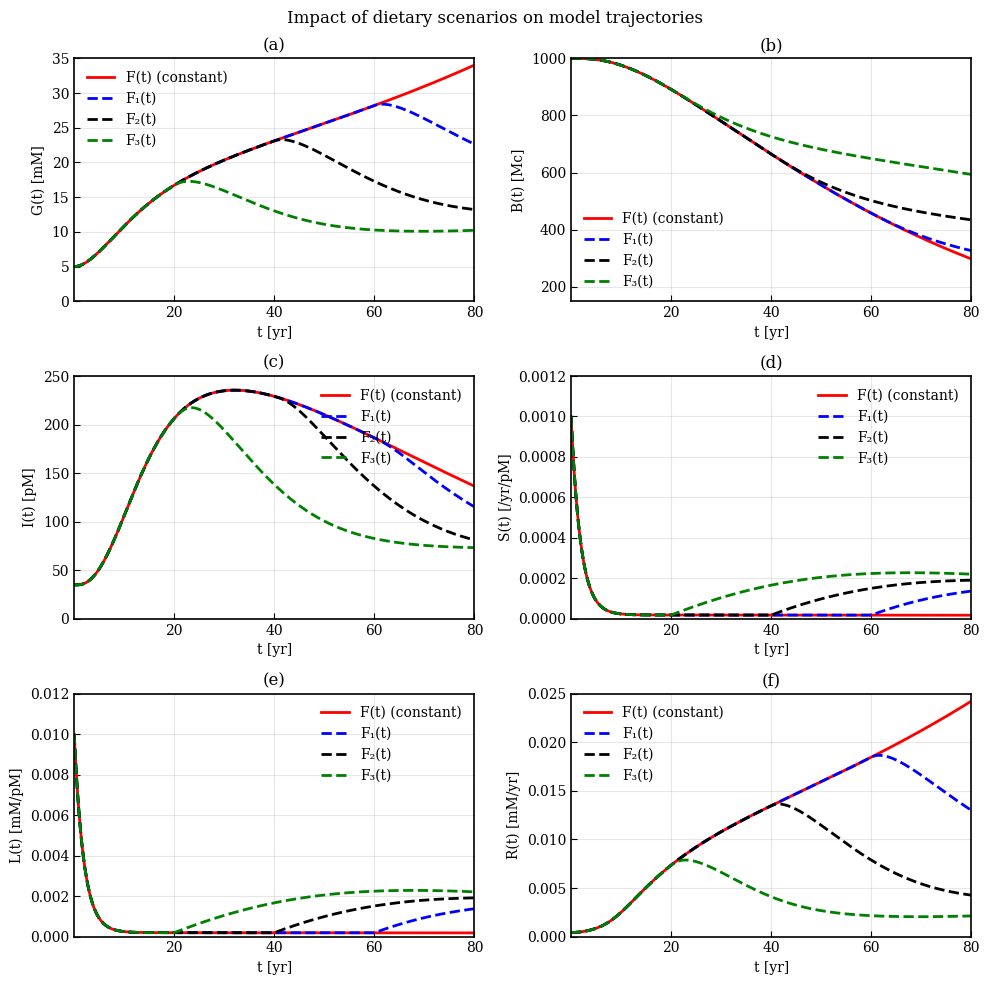

Red: Late-life avg G = 32.77 mM
F1: Late-life avg G = 24.08 mM
F2: Late-life avg G = 13.65 mM
F3: Late-life avg G = 10.15 mM


In [ ]:
# Excess food intake effect

# Plot styling
mpl.rcParams.update({
    "text.usetex": False,    # LaTeX for all text
    "font.family": "serif",  # Serif font for paper style
    "axes.linewidth": 1.2,   # Thicker border lines
    "xtick.direction": "in", # Inward ticks
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,  # No legend border
    "axes.facecolor": "white", # Clean white background
})

# Extend to t=80 yr (finer grid for smooth curves)
t_span = jnp.linspace(0, 80, 2000)
A0 = 18.0  # Starting age

# PARAMETERS
# Update "Red" params to include A0
params_red = params_cases['Red'].copy()
params_red['A0'] = A0
params_red['F'] = 500.0  # Excess level

# Initial conditions for Red case
y0_red = jnp.array([
    params_red['G_0'],    # G0
    params_red['B_0'],    # B0
    params_red['I_0'],    # I0
    params_red['S_0'],    # S0
    params_red['L_0'],    # L0
    A0                    # A0
])

# Scenarios dict: F_type as int (0=constant/inf, 1=60yr, 2=40yr, 3=20yr drop)
scenarios = {
    'Red': {'params': params_red, 'F_type': 0, 'color': 'red', 'style': '-', 'label': 'F(t) (constant)'},
    'F1': {'params': params_red, 'F_type': 1, 'color': 'blue', 'style': '--', 'label': 'F₁(t)'},
    'F2': {'params': params_red, 'F_type': 2, 'color': 'black', 'style': '--', 'label': 'F₂(t)'},
    'F3': {'params': params_red, 'F_type': 3, 'color': 'green', 'style': '--', 'label': 'F₃(t)'}
}

# ODE SYSTEM
# Updated ODE RHS: Inline thresh computation with JAX conditionals
def ode_rhs_timevar(t, y, args):
    params = args['params']
    F_type = args['F_type']
    G, B, I, S, L, A = y

    # Time-varying F: Chain jnp.where for branches
    # F_type 0: always 500 (thresh=inf)
    # F_type 1: 500 if t<60 else 0
    # F_type 2: 500 if t<40 else 0
    # F_type 3: 500 if t<20 else 0
    F = jnp.where(F_type == 0, params['F'],  # Constant
                  jnp.where(F_type == 1, jnp.where(t < 60.0, params['F'], 0.0),
                            jnp.where(F_type == 2, jnp.where(t < 40.0, params['F'], 0.0),
                                      jnp.where(F_type == 3, jnp.where(t < 20.0, params['F'], 0.0), 0.0))))  # Fallback 0
    Y = params['Y']  # Still 0


    # Renal R(G(t)) from Eq. 8
    discriminant = 4 * params['rho_GR'] * G + (G - params['G_R'] - params['rho_GR'])**2
    R = (params['s_GR'] / 2) * (jnp.sqrt(jnp.maximum(discriminant, 0.0)) + (G - params['G_R'] - params['rho_GR']))

    # Eq. 1: Glucose
    dGdt = params['k_max_G'] * jnp.exp(-L * I * G) - S * I * G - R

    # Eq. 2: Beta-cell mass
    dBdt = params['k_B'] * jnp.exp(-params['lambda_BA'] * (A - params['A0'])) - params['k_OB_G'] * G * B

    # Eq. 3: Insulin (Hill)
    hill = G**params['gamma_IG'] / (params['G_I50']**params['gamma_IG'] + G**params['gamma_IG'])
    dIdt = -params['k_OI'] * I + (B / params['B0_N']) * params['k_max_I'] * hill

    # Eq. 4: Peripheral sensitivity S
    dSdt = params['k_S'] - params['k_OS'] * S + params['k_SY'] * Y - params['k_OSF'] * F * S - params['k_OSA'] * (A - params['A0']) * S

    # Eq. 5: Central sensitivity L
    dLdt = params['k_L'] - params['k_OL'] * L + params['k_LY'] * Y - params['k_OLF'] * F * L - params['k_OLA'] * (A - params['A0']) * L

    # Eq. 6: Age
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

# Solve
def solve_ode_timevar(args, t_span, y0):
    # Direct lambda: Passes full args to ode_rhs_timevar
    vector_field = lambda t, y, _: ode_rhs_timevar(t, y, args)

    term = diffrax.ODETerm(vector_field)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        term, solver,
        t0=t_span[0], t1=t_span[-1],
        dt0=0.1, y0=y0,
        saveat=diffrax.SaveAt(ts=t_span)
    )
    return sol.ys  # Shape: (n_times, 6)


# Simulate all scenarios
solutions = {}
for name, info in scenarios.items():
    args = {'params': info['params'], 'F_type': info['F_type']}
    sol = solve_ode_timevar(args, t_span, y0_red)
    solutions[name] = sol

# Plot Fig. 5: 3x2 subplots
fig, axs = plt.subplots(3, 2, figsize=(10, 10))
age = t_span # Plot vs. age [yr]

for name, info in scenarios.items():
    sol = solutions[name]
    color, style, label = info['color'], info['style'], info['label']


    # print(f"{name} I min max: {sol[:,2].min()} {sol[:,2].max()}")  # Added to diagnose max I

    axs[0,0].plot(age, sol[:,0], color=color, linestyle=style, linewidth=2, label=label)

    axs[0,1].plot(age, sol[:,1], color=color, linestyle=style, linewidth=2, label=label)

    axs[1,0].plot(age, sol[:,2], color=color, linestyle=style, linewidth=2, label=label)

    axs[1,1].plot(age, sol[:,3], color=color, linestyle=style, linewidth=2, label=label)

    axs[2,0].plot(age, sol[:,4], color=color, linestyle=style, linewidth=2, label=label)

    R_vals = vmap(lambda g: compute_R(g, info['params']))(sol[:,0])
    axs[2,1].plot(age, R_vals, color=color, linestyle=style, linewidth=2, label=label)

# Formatting
axs[0,0].set_title('(a)')
axs[0,0].set_ylabel(r"G(t) [mM]")
axs[0,0].set_xlim(0, 80)
axs[0,0].set_ylim(0, 35)
axs[0,0].legend()

axs[0,1].set_title('(b)')
axs[0,1].set_ylabel(r"B(t) [Mc]")
axs[0,1].set_xlim(0, 80)
axs[0,1].set_ylim(150, 1000)
axs[0,1].legend()

axs[1,0].set_title('(c)')
axs[1,0].set_ylabel(r"I(t) [pM]")
axs[1,0].set_xlim(0, 80)
axs[1,0].set_ylim(0, 250)
axs[1,0].legend(loc='upper right')

axs[1,1].set_title('(d)')
axs[1,1].set_ylabel(r"S(t) [/yr/pM]")
axs[1,1].set_xlim(0, 80)
axs[1,1].set_ylim(0, 0.0012)
axs[1,1].legend()

axs[2,0].set_title('(e)')
axs[2,0].set_ylabel(r"L(t) [mM/pM]")
axs[2,0].set_xlim(0, 80)
axs[2,0].set_ylim(0, 0.012)
axs[2,0].legend()

axs[2,1].set_title('(f)')
axs[2,1].set_ylabel(r"R(t) [mM/yr]")
axs[2,1].set_xlim(0, 80)
axs[2,1].set_ylim(0, 0.025)
axs[2,1].legend()

for ax in axs.flat:
    ax.set_xlabel('t [yr]')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([20, 40, 60, 80])  # Only show these tick marks

plt.suptitle("Impact of dietary scenarios on model trajectories")
plt.tight_layout()
save_figure(fig,"Impact of dietary scenarios on model trajectories")
plt.show()


# Print late-life averages
for name in scenarios:
    late_G = jnp.mean(solutions[name][-200:, 0])  # Avg G over last ~2 yr
    print(f"{name}: Late-life avg G = {late_G:.2f} mM")


# **NHANES data Processing**

In [ ]:
# ============================================================================
# LOAD NHANES DATA FILES FROM GOOGLE DRIVE
# ============================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
file_path = "/content/drive/MyDrive/Colab Notebooks/PAXRAW_C.xpt"
demo_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/DEMO_C.xpt"
gluc_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/L10AM_C.xpt"
DR1TOT_C = "/content/drive/MyDrive/Colab Notebooks/Datasets/DR1TOT_C.xpt"

# Load datasets
demo_df = pd.read_sas(demo_path)
gluc_df = pd.read_sas(gluc_path)
dr1tot_df = pd.read_sas(DR1TOT_C)

# Quick verification
print("Datasets loaded successfully\n")


print("DEMO_C shape:", demo_df.shape)
print("GLUC_C shape:", gluc_df.shape)
print("DR1TOT_C shape:", dr1tot_df.shape)
#print("Glucose stats:", gluc_df["LBDGLUSI"].describe())
#print("Insulin stats:", gluc_df["LBDINSI"].describe())

cache_file = "nhanes_cached.pkl"
if os.path.exists(cache_file):

    print("Loading NHANES data from cache...")

    with open(cache_file, "rb") as f:
        data = pickle.load(f)

    print("Loaded cached dataset.")
    print("Rows:", len(data))

else:

    print("No cache found. Running full NHANES processing...")

    # Load demographic data
    demo, _ = pyreadstat.read_xport(
        demo_path,
        usecols=["SEQN", "WTMEC2YR", "RIDAGEYR", "RIAGENDR"]
    )

    # Load glucose / insulin data
    gluc, _ = pyreadstat.read_xport(gluc_path)

    # Load accelerometer data
    accel, _ = pyreadstat.read_xport(
        file_path,
        usecols=["SEQN", "PAXINTEN", "PAXSTAT", "PAXDAY"]
    )

    # Load dietary intake
    diet = pd.read_sas(DR1TOT_C)
    diet = diet[["SEQN", "DR1TKCAL"]]
    diet = diet[diet["DR1TKCAL"] > 0]


    # Merge datasets

    data = demo.copy()

    data = data.merge(gluc, on="SEQN", how="left")
    data = data.merge(diet, on="SEQN", how="left")

    # Process accelerometer data

    accel = accel[accel["PAXSTAT"] == 1]

    accel["intensity"] = pd.cut(
        accel["PAXINTEN"],
        bins=[-1, 99, 759, 2019, np.inf],
        labels=["sedentary", "light", "moderate", "vigorous"]
    )

    daily = (
        accel.groupby(["SEQN", "PAXDAY", "intensity"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    intensity_cols = ["sedentary", "light", "moderate", "vigorous"]

    for col in intensity_cols:
        if col not in daily.columns:
            daily[col] = 0

    daily["total_minutes"] = daily[intensity_cols].sum(axis=1)

    daily = daily[daily["total_minutes"] >= 600]

    person_activity = daily.groupby("SEQN")[intensity_cols + ["total_minutes"]].mean()

    person_activity["mvpa_minutes"] = (
        person_activity["moderate"] + person_activity["vigorous"]
    )

    data = data.merge(person_activity[["mvpa_minutes"]], on="SEQN", how="left")

    # Rename columns

    data = data.rename(
        columns={
            "RIDAGEYR": "age",
            "RIAGENDR": "gender",
            "WTMEC2YR": "weight",
            "DR1TKCAL": "calories",
            "LBDGLUSI": "glucose",
            "LBDINSI": "insulin"
        }
    )


    # Keep adults only

    data = data[data["age"] >= 18].copy()

    # ---------------------------------------------------------------------
    # Remove rows with missing required variables
    # ---------------------------------------------------------------------
    required_columns = ["age", "weight", "mvpa_minutes", "calories","glucose","insulin"]

    data = data.dropna(subset=required_columns)
    print("Datasets loaded successfully")

    # SAVE CACHE
    print("Saving processed dataset...")

    with open(cache_file, "wb") as f:
        pickle.dump(data, f)

    print("Cache saved:", cache_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded successfully

DEMO_C shape: (10122, 44)
GLUC_C shape: (3356, 7)
DR1TOT_C shape: (9643, 160)
Loading NHANES data from cache...
Loaded cached dataset.
Rows: 2084


In [ ]:
# Cleaned data and summary

# Remove invalid weights, calories, mvpa_minutes
data = data[data["weight"] > 0]

data = data[(data["calories"] > 500) & (data["calories"] < 6000)] # ensure reasonable ranges

data = data[(data["mvpa_minutes"] >= 0) & (data["mvpa_minutes"] < 600)] # ensure reasonable ranges

print("Remaining individuals:", len(data))

print("Age range:", data["age"].min(), "-", data["age"].max())

print("Mean MVPA:", data["mvpa_minutes"].mean())

print("Mean calories:", data["calories"].mean())

data.head()


Remaining individuals: 2052
Age range: 18.0 - 85.0
Mean MVPA: 81.24647266313933
Mean calories: 2184.5375243664716


,SEQN,gender,age,weight,WTSAF2YR,LBXGLU,glucose,LBXCPSI,LBXIN,insulin,calories,mvpa_minutes
0,21005.0,1.0,19.0,5824.782465,14084.10,87.6,4.863,0.591,11.26,67.56,2984.0,102.428571
15,21020.0,2.0,55.0,29102.083555,65607.89,88.1,4.890,0.717,9.05,54.30,2575.0,30.571429
20,21025.0,2.0,18.0,13772.570375,33084.63,85.6,4.752,0.447,3.22,19.32,990.0,111.714286
24,21029.0,1.0,40.0,100099.630952,211685.72,92.9,5.157,0.987,11.02,66.12,4907.0,91.428571
28,21033.0,2.0,57.0,25488.344933,60329.07,96.3,5.346,0.919,11.52,69.12,1042.0,109.714286


##**Step 6: Fitting behavioral models**

Saved: age_trends_20260514_012017.png


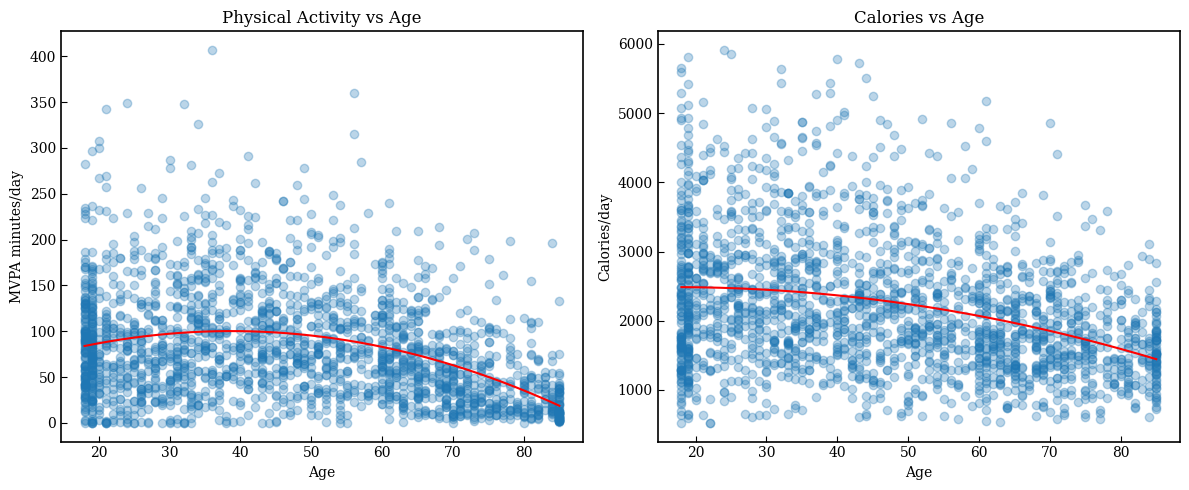

In [ ]:
# AGE TRENDS: PHYSICAL ACTIVITY AND CALORIES VS AGE FOR THE WHOLE DATASET

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MVPA vs Age

axes[0].scatter(data['age'], data['mvpa_minutes'], alpha=0.3)

mvpa_coeffs = np.polyfit(data['age'], data['mvpa_minutes'], 2)
mvpa_poly = np.poly1d(mvpa_coeffs)

x = np.linspace(data['age'].min(), data['age'].max(), 200)

axes[0].plot(x, mvpa_poly(x), color='red')

axes[0].set_title("Physical Activity vs Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("MVPA minutes/day")

# Calories vs Age
axes[1].scatter(data['age'], data['calories'], alpha=0.3)

cal_coeffs = np.polyfit(data['age'], data['calories'], 2)
cal_poly = np.poly1d(cal_coeffs)

axes[1].plot(x, cal_poly(x), color='red')

axes[1].set_title("Calories vs Age")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Calories/day")

# Layout + Save
plt.tight_layout()
save_figure(fig, "age_trends")
plt.show()

Fitting behavioral models...

Behavior models fitted
MVPA polynomial coefficients: [-7.61531146e-04  6.24084275e-02  3.13605642e+00]
Calories polynomial coefficients: [-2.25155146e-01  7.64940956e+00  2.42041782e+03]
MVPA residual std: 0.928798228369071
Calories residual std: 904.1731316710991
length of data: 2052
Shape check:
F: (1000,) Y: (1000,)

Basic stats:
F -> min: 0.0 max: 910.30273 mean: 234.16486
Y -> min: 17.884586 max: 216.45584 mean: 91.48856

Constant mode check:
Unique Y: [50.]
Unique F: [200.]

Calories below baseline → F should be 0:
Max F: 0.0

Determinism check:
F identical: False
Y identical: False

MVPA positivity check:
Any negative? False

Trend vs noisy output:
Mean of trend: 4.1212015
Mean of sampled: 4.4057508


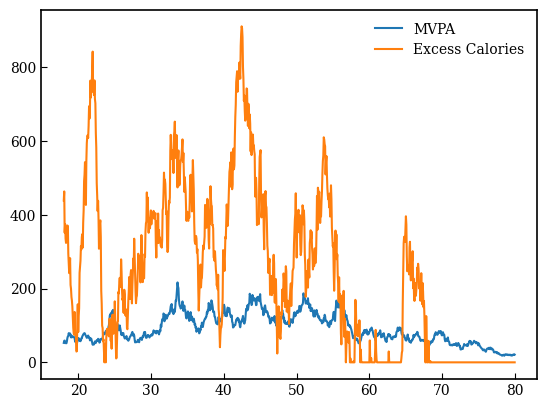

In [ ]:
# =============================================================================
# FIT AGE-DEPENDENT BEHAVIORAL MODELS
# =============================================================================

print("Fitting behavioral models...")

# Fit quadratic polynomial trends

mvpa_coeffs = np.polyfit(data["age"],np.log(data["mvpa_minutes"] + 1),2) # Logtransform since mvpa is highly skewed, many small values few large values

calorie_coeffs = np.polyfit(data["age"],data["calories"],2)

# Create polynomial models

mvpa_poly = np.poly1d(mvpa_coeffs)
calorie_poly = np.poly1d(calorie_coeffs)


# Compute residual variability

mvpa_residuals = np.log(data["mvpa_minutes"] + 1) - mvpa_poly(data["age"])

calorie_residuals = data["calories"] - calorie_poly(data["age"])


mvpa_sigma = np.std(mvpa_residuals)

calorie_sigma = np.std(calorie_residuals)


print("\nBehavior models fitted")
print("MVPA polynomial coefficients:", mvpa_coeffs)
print("Calories polynomial coefficients:", calorie_coeffs)
print("MVPA residual std:", mvpa_sigma)
print("Calories residual std:", calorie_sigma)
print("length of data:",len(data))


# Store results for later use
behavior_models = {
    # store coefficients ONLY
    "mvpa_coeffs": jnp.array(mvpa_coeffs),
    "calorie_coeffs": jnp.array(calorie_coeffs),
    "mvpa_sigma": mvpa_sigma,
    "calorie_sigma": calorie_sigma
}

def generate_correlated_noise(key, shape, rho=0.95):
    """
    Generate temporally correlated AR(1) noise.

    rho close to 1:
        smoother trajectories
    rho smaller:
        noisier trajectories
    """
    eps = jax.random.normal(key, shape=shape)

    def step(carry, eps_t):
        new = rho * carry + jnp.sqrt(1 - rho**2) * eps_t
        return new, new
    _, noise = jax.lax.scan(step, 0.0, eps)
    return noise

def evaluate_poly(coeffs, x):
    return jnp.polyval(coeffs, x)

# =========================================================
# BEHAVIOR TRAJECTORIES
# =========================================================

def generate_behavior_trajectories(
    age_grid,
    mvpa0,
    cal0,
    behavior_mode,
    key
):


    # CONSTANT BEHAVIOR

    if behavior_mode == "constant":
        mvpa_traj = jnp.ones_like(age_grid) * mvpa0
        cal_traj  = jnp.ones_like(age_grid) * cal0

    # DYNAMIC BEHAVIOR

    elif behavior_mode == "dynamic":
        # AGE-DEPENDENT MEAN TRENDS
         mvpa_mean = evaluate_poly(
            behavior_models["mvpa_coeffs"],
            age_grid
          )
         cal_mean = evaluate_poly(
            behavior_models["calorie_coeffs"],
            age_grid
          )
        # CORRELATED STOCHASTICITY

         key1, key2 = jax.random.split(key)

         mvpa_noise = generate_correlated_noise(
            key1,
            shape=age_grid.shape,
            rho=0.98
        )

         cal_noise = generate_correlated_noise(
            key2,
            shape=age_grid.shape,
            rho=0.98
        )


        # MVPA TRAJECTORY

         mvpa_traj = jnp.exp(
            mvpa_mean
            +
            0.35 * behavior_models["mvpa_sigma"] * mvpa_noise
        )

        # CALORIE TRAJECTORY

         cal_traj = (
            cal_mean
            +
            0.25 * behavior_models["calorie_sigma"] * cal_noise
        )


        # Safety clipping

        #mvpa_traj = jnp.clip(mvpa_traj, 0.0, 400.0)

        #cal_traj = jnp.clip(cal_traj, 800.0, 5000.0)



    #elif behavior_mode == "dynamic":
        # age-dependent trends
        #mvpa_mean = behavior_models["mvpa_poly"](age_grid)

        # SHIFT so it matches initial condition
        #mvpa_mean = mvpa_mean - mvpa_mean[0] + jnp.log(mvpa0 + 1)
        #cal_mean = behavior_models["calorie_poly"](age_grid)
        #cal_mean = cal_mean - cal_mean[0] + cal0

        #key1, key2 = jax.random.split(key)

        #mvpa_traj = jnp.exp(
            #mvpa_mean +
            #behavior_models["mvpa_sigma"] *
            #jax.random.normal(key1, shape=age_grid.shape)
        #)

        #cal_traj = (
            #cal_mean +
            #behavior_models["calorie_sigma"] *
            #jax.random.normal(key2, shape=age_grid.shape)
        #)

    # EXCESS CALORIES
    baseline = 2000.0
    #F_traj = jnp.maximum(cal_traj - baseline, 0.0)
    F_traj = jax.nn.softplus(cal_traj - baseline)

    Y_traj = mvpa_traj

    return F_traj, Y_traj

key = jax.random.PRNGKey(42)
# split keys for different calls
age_grid = jnp.linspace(18, 80, 1000)

key, subkey = jax.random.split(key)
F, Y = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey)

print("Shape check:")
print("F:", F.shape, "Y:", Y.shape)

print("\nBasic stats:")
print("F -> min:", F.min(), "max:", F.max(), "mean:", F.mean())
print("Y -> min:", Y.min(), "max:", Y.max(), "mean:", Y.mean())


# Constant mode does NOT need randomness
F_const, Y_const = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "constant", key)

print("\nConstant mode check:")
print("Unique Y:", jnp.unique(Y_const))
print("Unique F:", jnp.unique(F_const))


F_low, _ = generate_behavior_trajectories(age_grid, 50.0, 1800.0, "constant", key)
print("\nCalories below baseline → F should be 0:")
print("Max F:", F_low.max())


#USE DIFFERENT KEYS

key, subkey1 = jax.random.split(key)
key, subkey2 = jax.random.split(key)

F1, Y1 = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey1)
F2, Y2 = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey2)

print("\nDeterminism check:")
print("F identical:", jnp.allclose(F1, F2))
print("Y identical:", jnp.allclose(Y1, Y2))


print("\nMVPA positivity check:")
print("Any negative?", (Y < 0).any())


mvpa_mean = evaluate_poly(behavior_models["mvpa_coeffs"], age_grid)

print("\nTrend vs noisy output:")
print("Mean of trend:", mvpa_mean.mean())
print("Mean of sampled:", jnp.log(Y).mean())


plt.plot(age_grid, Y, label="MVPA")
plt.plot(age_grid, F, label="Excess Calories")
plt.legend()
plt.show()

Saved: residuals_20260514_012020.png


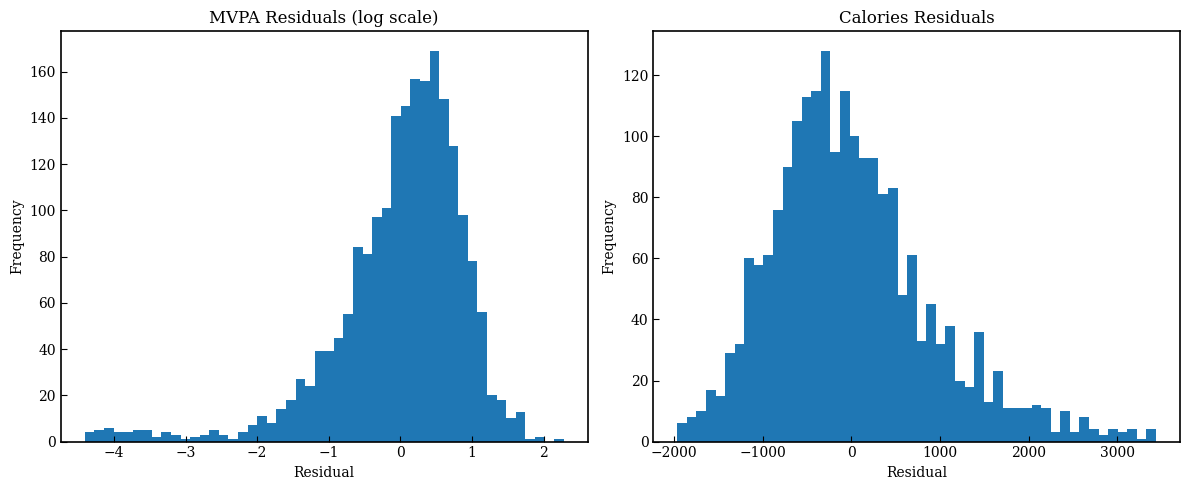

In [ ]:
# RESIDUAL DISTRIBUTIONS

fig, axes = plt.subplots(1,2, figsize=(12,5))

# MVPA residuals
axes[0].hist(mvpa_residuals, bins=50)
axes[0].set_title("MVPA Residuals (log scale)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")

# Calories residuals
axes[1].hist(calorie_residuals, bins=50)
axes[1].set_title("Calories Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
save_figure(fig, "residuals")
plt.show()

## **Step 7: Build the initial conditions**

In [ ]:
# =============================================================================
# BUILD INITIAL CONDITIONS FROM YOUNG NHANES INDIVIDUALS
# =============================================================================

n = 100   # number of individuals to sample

required_cols = [
    "age",
    "glucose",
    "insulin",
    "mvpa_minutes",
    "calories"
]

missing = [c for c in required_cols if c not in data.columns]

if missing:
    raise ValueError("Required NHANES columns missing: " + str(missing))


# Select young adults
young = data[(data["age"] >= 18) & (data["age"] <= 22)].copy()

if len(young) == 0:
    raise ValueError("No individuals aged 18–22 found")


# Remove rows with missing values
young = young.dropna(subset=required_cols)


if len(young) < n:
    raise ValueError(
        f"Requested {n} individuals but only {len(young)} have complete data"
    )


# Randomly sample individuals
sample = young.sample(n, random_state=42)

N_samples=100


# EMPIRICAL INITIALIZATION
empirical_subset = sample.sample(N_samples, random_state=42)

empirical_G0 = jnp.array(empirical_subset["glucose"].values)
empirical_I0 = jnp.array(empirical_subset["insulin"].values)
empirical_age = jnp.array(empirical_subset["age"].values)
empirical_mvpa = jnp.array(empirical_subset["mvpa_minutes"].values)
empirical_calories = jnp.array(empirical_subset["calories"].values)


# Build initial state vectors
initials = []

for _, row in sample.iterrows():

    A0 = float(row["age"])
    G0= float(row["glucose"])
    I0= float(row["insulin"])
    MVPA0 = float(row["mvpa_minutes"])
    CAL0 = float(row["calories"])

    # Default physiological states
    #B0 = params_base['B_0']
    #S0 = params_base['S_0']
    #L0 = params_base['L_0']

    initials.append([
        G0,     # Glucose
        #B0,     # Beta cells
        I0,     # Insulin
        #S0,     # Peripheral sensitivity
        #L0,     # Liver sensitivity
        A0,     # Age
        MVPA0,  # Behavior (extra)
        CAL0    # Behavior (extra)
    ])


initials = np.array(initials)
initials_all=initials

print("\nYoung calibration cohort created")
print("Individuals:", len(initials))
print("Mean age:", np.mean(initials[:,2]))
print("Mean MVPA:", np.mean(initials[:,3]))
print("Mean calories:", np.mean(initials[:,4]))
print("Initials:",initials.shape)



Young calibration cohort created
Individuals: 100
Mean age: 19.13
Mean MVPA: 86.29857142857144
Mean calories: 2199.18
Initials: (100, 5)


In [ ]:
# =============================================================================
# BUILD AGE-BINNED NHANES STATISTICS
# =============================================================================
data_filtered = data[(data["age"] >= 18) & (data["age"] <= 80)].copy()
bins = [10,20,30,40,50,60,70,80]
age_mid = np.array([15,25,35,45,55,65,75])
data_filtered["age_bin"] = pd.cut( data_filtered["age"], bins=bins, labels=age_mid )
grouped = ( data_filtered.groupby("age_bin", observed=True)[["glucose","insulin","mvpa_minutes","calories"]] .agg(["mean","std","count"]) .dropna() )
results = { "age_mid": age_mid, "G_mean": grouped["glucose"]["mean"].values, "G_sd": grouped["glucose"]["std"].values, "I_mean": grouped["insulin"]["mean"].values, "I_sd": grouped["insulin"]["std"].values, "mvpa_minutes_mean": grouped["mvpa_minutes"]["mean"].values, "mvpa_minutes_std": grouped["mvpa_minutes"]["std"].values, "calories_mean": grouped["calories"]["mean"].values, "calories_std": grouped["calories"]["std"].values, }

print("Age-binned statistics built")
print("Age midpoints:", results["age_mid"])
print("Mean glucose:", results["G_mean"])
print("Mean insulin:", results["I_mean"])
print("Mean mvpa:", results["mvpa_minutes_mean"])
print("Mean calories:", results["calories_mean"])

# STORE TARGET TRAJECTORIES
age_midpoints = results["age_mid"]
G_mean_target = results["G_mean"]
G_sd_target = results["G_sd"]
I_mean_target = results["I_mean"]
I_sd_target = results["I_sd"]
mvpa_minutes_mean_target = results["mvpa_minutes_mean"]
mvpa_minutes_sd_target = results["mvpa_minutes_std"]
calories_mean_target = results["calories_mean"]
calories_sd_target = results["calories_std"]
print("Target trajectories saved.")

Age-binned statistics built
Age midpoints: [15 25 35 45 55 65 75]
Mean glucose: [5.01482022 5.02229801 5.30031818 5.70978182 6.30467068 6.54505212
 6.26537198]
Mean insulin: [73.41191011 63.98602649 79.12422078 60.91221818 69.6253012  82.24495114
 66.62289855]
Mean mvpa: [ 86.94489032  86.92715232 103.45825603 100.70649351  91.46586345
  68.67612843  46.98481712]
Mean calories: [2379.89513109 2516.2218543  2519.16883117 2313.54545455 2113.53012048
 1871.96742671 1737.97101449]
Target trajectories saved.


Saved: age_binned_statistics plots_20260514_012021.png


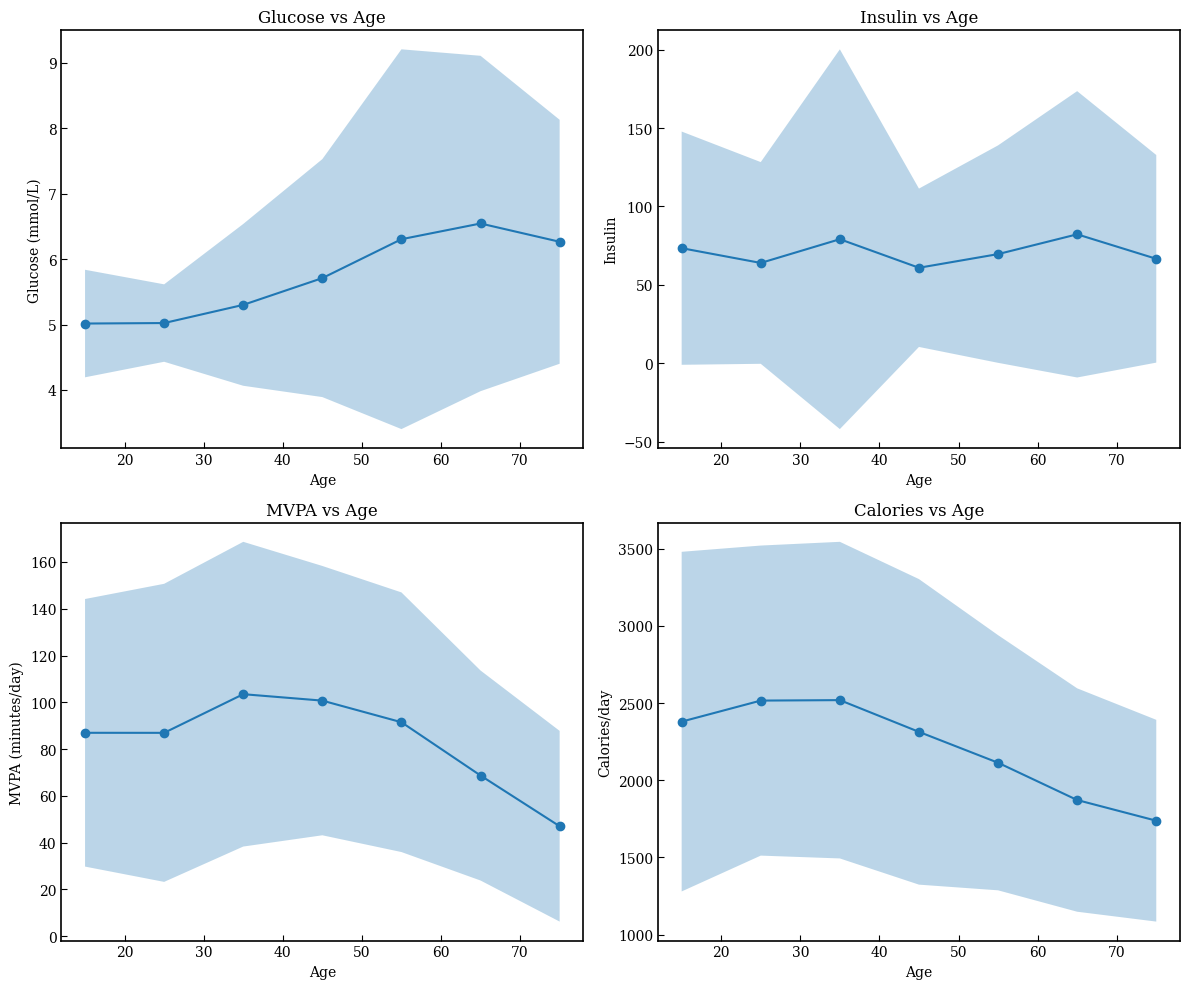

In [ ]:
# =============================================================================
# AGE-BINNED MEAN ± STANDARD DEVIATION PLOTS
# =============================================================================

age = results["age_mid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Glucose
axes[0,0].plot(age, results["G_mean"], marker='o')
axes[0,0].fill_between(
    age,
    results["G_mean"] - results["G_sd"],
    results["G_mean"] + results["G_sd"],
    alpha=0.3
)
axes[0,0].set_title("Glucose vs Age")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Glucose (mmol/L)")

# Insulin
axes[0,1].plot(age, results["I_mean"], marker='o')
axes[0,1].fill_between(
    age,
    results["I_mean"] - results["I_sd"],
    results["I_mean"] + results["I_sd"],
    alpha=0.3
)
axes[0,1].set_title("Insulin vs Age")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Insulin")

# MVPA
axes[1,0].plot(age, results["mvpa_minutes_mean"], marker='o')
axes[1,0].fill_between(
    age,
    results["mvpa_minutes_mean"] - results["mvpa_minutes_std"],
    results["mvpa_minutes_mean"] + results["mvpa_minutes_std"],
    alpha=0.3
)
axes[1,0].set_title("MVPA vs Age")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("MVPA (minutes/day)")

# Calories
axes[1,1].plot(age, results["calories_mean"], marker='o')
axes[1,1].fill_between(
    age,
    results["calories_mean"] - results["calories_std"],
    results["calories_mean"] + results["calories_std"],
    alpha=0.3
)
axes[1,1].set_title("Calories vs Age")
axes[1,1].set_xlabel("Age")
axes[1,1].set_ylabel("Calories/day")

# Final layout
plt.tight_layout()
save_figure(fig, "age_binned_statistics plots")
plt.show()

Age-binned statistics built
Saved: age_binned_percentile_plots_20260514_012022.png


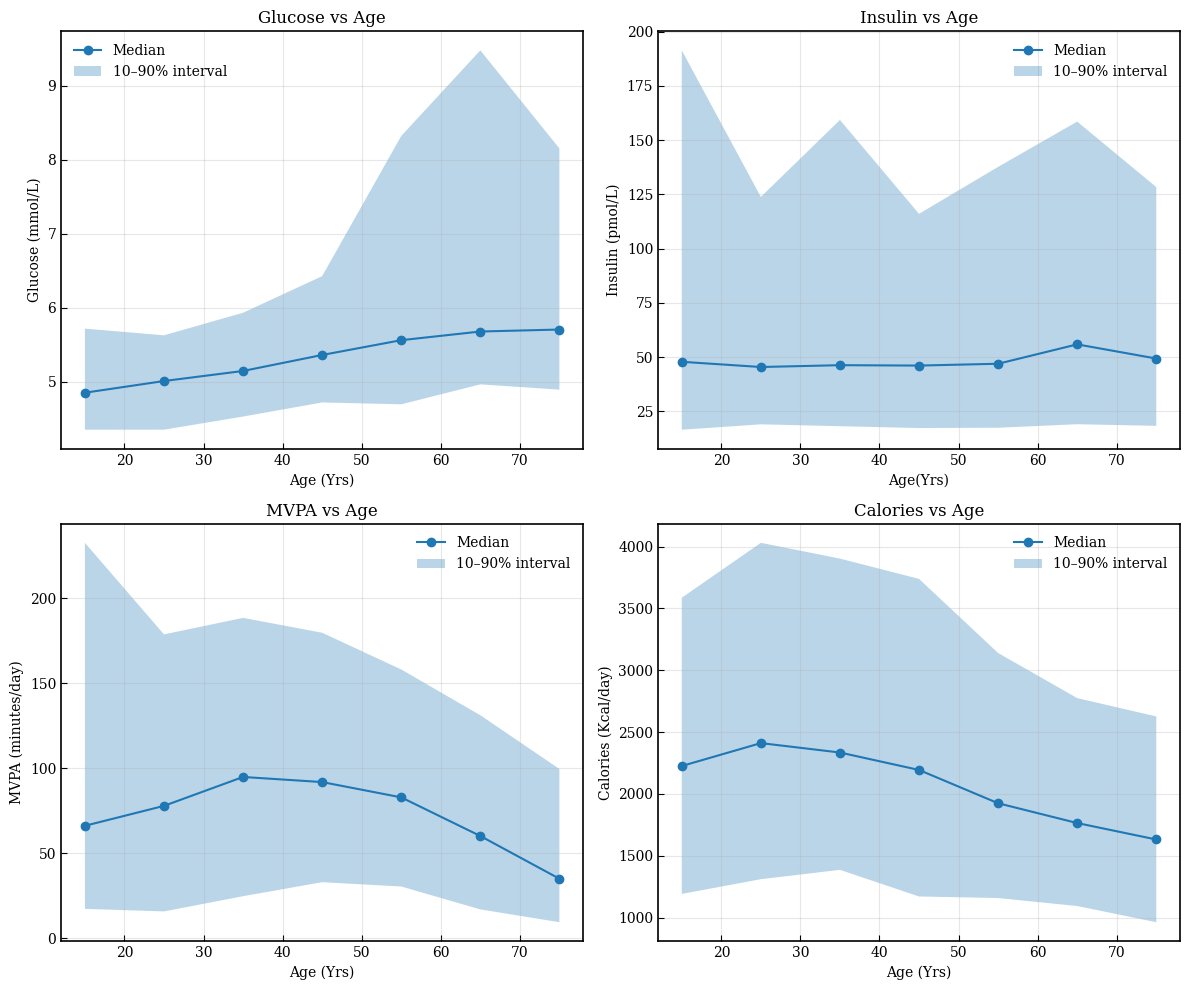

In [ ]:
# =============================================================================
# BUILD AGE-BINNED NHANES STATISTICS
# =============================================================================
data_filtered = data[(data["age"] >= 20) & (data["age"] <= 80)].copy()
bins = [10,20,30,40,50,60,70,80]
age_mid = np.array([15,25,35,45,55,65,75])
data_filtered["age_bin"] = pd.cut( data_filtered["age"], bins=bins, labels=age_mid )

grouped = data_filtered.groupby("age_bin", observed=True)

results = {
    "age_mid": age_mid,

    "G_p10": grouped["glucose"].quantile(0.1).values,
    "G_p50": grouped["glucose"].quantile(0.5).values,
    "G_p90": grouped["glucose"].quantile(0.9).values,

    "I_p10": grouped["insulin"].quantile(0.1).values,
    "I_p50": grouped["insulin"].quantile(0.5).values,
    "I_p90": grouped["insulin"].quantile(0.9).values,

    "mvpa_p10": grouped["mvpa_minutes"].quantile(0.1).values,
    "mvpa_p50": grouped["mvpa_minutes"].quantile(0.5).values,
    "mvpa_p90": grouped["mvpa_minutes"].quantile(0.9).values,

    "cal_p10": grouped["calories"].quantile(0.1).values,
    "cal_p50": grouped["calories"].quantile(0.5).values,
    "cal_p90": grouped["calories"].quantile(0.9).values,
}

print("Age-binned statistics built")
age_midpoints = results["age_mid"]

# =============================================================================
# AGE-BINNED PERCENTILE PLOTS
# =============================================================================

age = results["age_mid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -------------------------
# Glucose
# -------------------------
axes[0,0].plot(age, results["G_p50"], marker='o', label="Median")
axes[0,0].fill_between(
    age,
    results["G_p10"],
    results["G_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[0,0].set_title("Glucose vs Age")
axes[0,0].set_xlabel("Age (Yrs)")
axes[0,0].set_ylabel("Glucose (mmol/L)")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# -------------------------
# Insulin
# -------------------------
axes[0,1].plot(age, results["I_p50"], marker='o', label="Median")
axes[0,1].fill_between(
    age,
    results["I_p10"],
    results["I_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[0,1].set_title("Insulin vs Age")
axes[0,1].set_xlabel("Age(Yrs)")
axes[0,1].set_ylabel("Insulin (pmol/L)")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# -------------------------
# MVPA
# -------------------------
axes[1,0].plot(age, results["mvpa_p50"], marker='o', label="Median")
axes[1,0].fill_between(
    age,
    results["mvpa_p10"],
    results["mvpa_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[1,0].set_title("MVPA vs Age")
axes[1,0].set_xlabel("Age (Yrs)")
axes[1,0].set_ylabel("MVPA (minutes/day)")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# -------------------------
# Calories
# -------------------------
axes[1,1].plot(age, results["cal_p50"], marker='o', label="Median")
axes[1,1].fill_between(
    age,
    results["cal_p10"],
    results["cal_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[1,1].set_title("Calories vs Age")
axes[1,1].set_xlabel("Age (Yrs)")
axes[1,1].set_ylabel("Calories (Kcal/day)")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

# Layout
plt.tight_layout()
save_figure(fig, "age_binned_percentile_plots")
plt.show()

## **Fit a multivariate normal distribution to the (insulin, glucose) in the 18-22 age cohort**

In [ ]:
# FIT MULTIVARIATE NORMAL (GLUCOSE, INSULIN)
glucose = young["glucose"].values
insulin = young["insulin"].values
print("Min insulin:", insulin.min())

#log_insulin = np.log(np.clip(insulin, 1e-6, None))
log_insulin = np.log(insulin)

data_pairs = np.column_stack((glucose, log_insulin))


# Fit Gaussian
mean = np.mean(data_pairs, axis=0)
cov = np.cov(data_pairs.T)

print(data_pairs.shape)
print("Fitted mean:", mean)
print("Fitted covariance:", cov)

Min insulin: 4.26
(333, 2)
Fitted mean: [5.0239009  3.92838834]
Fitted covariance: [[0.64853198 0.17334269]
 [0.17334269 0.68761548]]


Saved: Actual histogram of glucose insulin pairs_20260514_012024.png


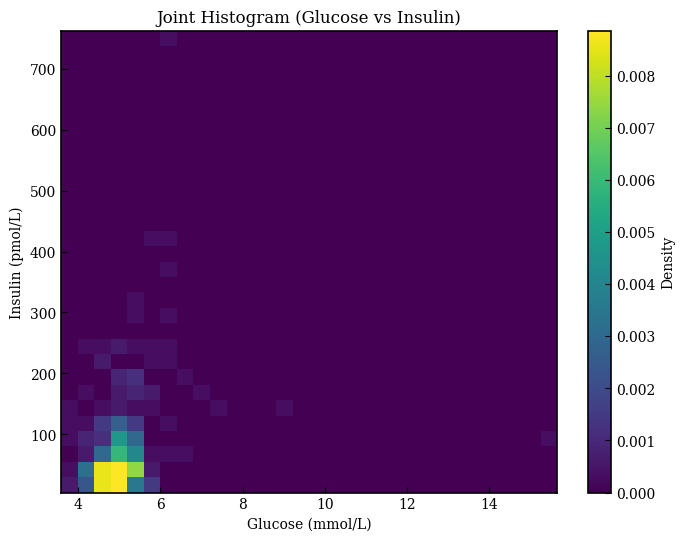

In [ ]:
# ACTUAL HISTOGRAM OF (GLUCOSE, INSULIN) PAIRS
plt.figure(figsize=(8, 6))

plt.hist2d(glucose, insulin, bins=30, density=True)

plt.xlabel("Glucose (mmol/L)")
plt.ylabel("Insulin (pmol/L)")
plt.title("Joint Histogram (Glucose vs Insulin)")

#plt.yscale("log")  # Add log scale

plt.colorbar(label="Density")
fig = plt.gcf()
save_figure(fig, "Actual histogram of glucose insulin pairs")
plt.show()

Any NaNs in Z? False
Any infs in Z? False
Saved: Fitted Histogram and scatter gaussian distribution_20260514_012025.png


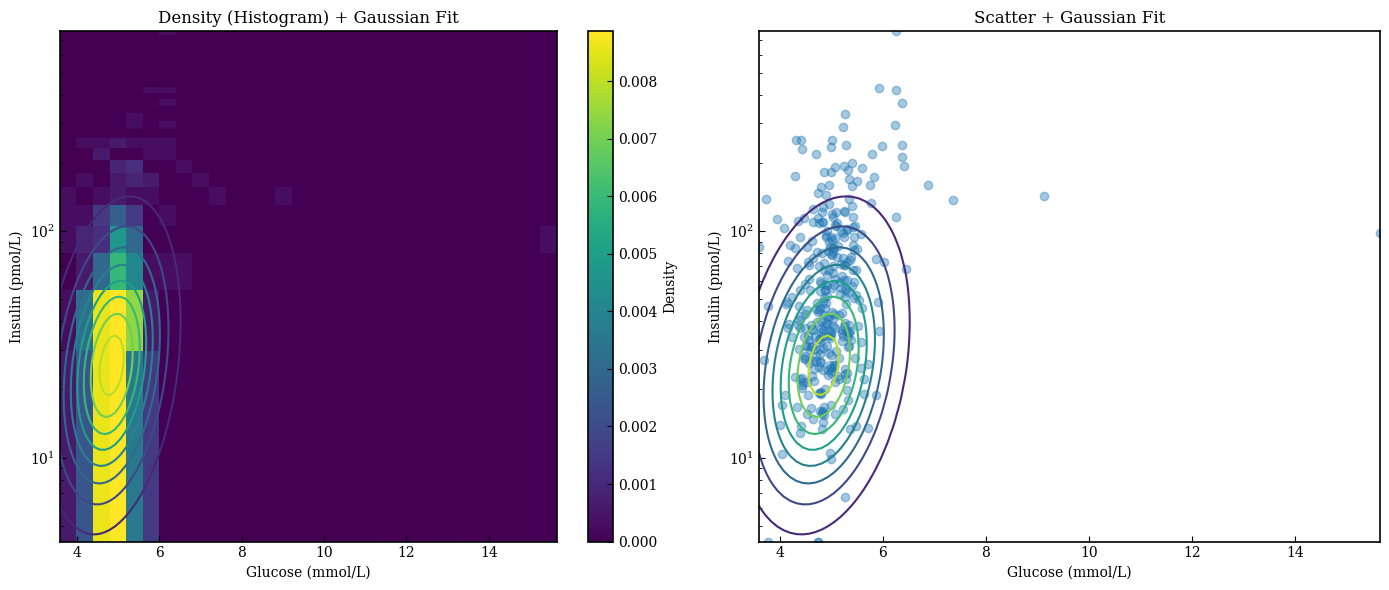

In [ ]:
# Plots of fitted distribution

# Grid
x = np.linspace(glucose.min(), glucose.max(), 100)
y = np.logspace(np.log10(insulin.min()), np.log10(insulin.max()), 100)

X, Y = np.meshgrid(x, y)

# Log-transform insulin
#log_Y = np.log(np.clip(Y, 1e-6, None))
log_Y = np.log(Y)
pos = np.dstack((X, log_Y))

# Gaussian in (G, log I)
rv = multivariate_normal(mean, cov)
Z_log = rv.pdf(pos)

# Jacobian
Z = Z_log / Y
print("Any NaNs in Z?", np.isnan(Z).any())
print("Any infs in Z?", np.isinf(Z).any())
#Z = np.nan_to_num(Z, nan=0.0, posinf=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
hist = axes[0].hist2d(glucose, insulin, bins=30, density=True)

axes[0].contour(X, Y, Z, levels=10)
axes[0].set_yscale("log")

axes[0].set_xlabel("Glucose (mmol/L)")
axes[0].set_ylabel("Insulin (pmol/L)")
axes[0].set_title("Density (Histogram) + Gaussian Fit")

fig.colorbar(hist[3], ax=axes[0], label="Density")

# Scatter
axes[1].scatter(glucose, insulin, alpha=0.4)
axes[1].contour(X, Y, Z, levels=10)
axes[1].set_yscale("log")

axes[1].set_xlabel("Glucose (mmol/L)")
axes[1].set_ylabel("Insulin (pmol/L)")
axes[1].set_title("Scatter + Gaussian Fit")

plt.tight_layout()
save_figure(fig, "Fitted Histogram and scatter gaussian distribution")
plt.show()

## **Defining Parameter Distributions over the model parameters**



  

In [ ]:
print(params_cases["Red"])

# PARAM DISTRIBUTIONS
theta_keys = [
  "lambda_BA",
    "k_OB_G",
    "k_OI",
    "k_OSF",
    "k_OSA",
    "k_OLF",
    "k_OLA"
]

param_dist = {
    "lambda_BA": {"mu": params_cases["Red"]["lambda_BA"], "sigma": 0.003},
    "k_OB_G":    {"mu": params_cases["Red"]["k_OB_G"], "sigma": 0.003},
    "k_OI":      {"mu": params_cases["Red"]["k_OI"],  "sigma": 0.02},
    "k_OSF":     {"mu": params_cases["Red"]["k_OSF"], "sigma": 0.003},
    "k_OSA":     {"mu": params_cases["Red"]["k_OSA"], "sigma": 0.003},
    "k_OLF":     {"mu": params_cases["Red"]["k_OLF"], "sigma": 0.003},
    "k_OLA":     {"mu": params_cases["Red"]["k_OLA"], "sigma": 0.003}
}

print("Initial guesses distribution")
print(param_dist)

mus = jnp.array([param_dist[k]["mu"] for k in theta_keys])
sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])

def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    return jnp.exp(jnp.log(mus) + sigmas * eps)

def build_params(param_sample):# take a sampled parameter vector and convert to a dictionary for the solver
    return {
        #**params_base,
        **params_cases["Red"],
        "lambda_BA": param_sample[0],
        "k_OB_G":    param_sample[1],
        "k_OI":      param_sample[2],
        "k_OSF":     param_sample[3],
        "k_OSA":     param_sample[4],
        "k_OLF":     param_sample[5],
        "k_OLA":     param_sample[6],
    }
key = jax.random.PRNGKey(0) #jax random seed

N_samples = 100  # keep small initially

# noise for reparameterization
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))

param_samples = vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps)

print(param_samples.shape)

# MULTIVARIATE INIT DISTRIBUTION
# Convert already computed mean/cov to jax arrays
mean_jax = jnp.array(mean)     # shape (2,)
cov_jax = jnp.array(cov)       # shape (2,2)

def sample_parameters(key, param_dist, init_mean, init_cov, N):

    # SPLIT MAIN RANDOM KEYS

    key_params, key_init, key_age, key_behavior = jax.random.split(key, 4)

    # SAMPLE INITIAL AGES

    ages = jax.random.choice(
        key_age,
        jnp.array(young["age"]),
        shape=(N,)
    )
    # SAMPLE BEHAVIORAL VARIABLES

    #mvpa_mean = behavior_models["mvpa_poly"](ages)
    mvpa_mean = evaluate_poly(behavior_models["mvpa_coeffs"], ages)

    key_mvpa, key_cal = jax.random.split(key_behavior)

    # MVPA sampled in LOG space
    mvpa = jnp.exp(
        mvpa_mean +
        behavior_models["mvpa_sigma"] *
        jax.random.normal(key_mvpa, shape=(N,))
    )

    # Calories sampled in normal space

    calorie_mean = evaluate_poly(
    behavior_models["calorie_coeffs"],
    ages
    )

    calories = (
        calorie_mean+
        behavior_models["calorie_sigma"]*
        jax.random.normal(key_cal, shape=(N,))
    )


    # CREATE RANDOM KEYS FOR EACH INDIVIDUAL
    keys = jax.random.split(key_params, N)
    samples = []
    matrix_samples = []

    # LOOP THROUGH SYNTHETIC INDIVIDUAL
    for i in range(N):
        subkey = keys[i]
        sample = {}

        # Split keys:
        # 7 parameter noises + 1 GI multivariate sample

        subkeys = jax.random.split(subkey, len(theta_keys) + 1)
        vector_samples = []

        # LOGNORMAL PARAMETER SAMPLING

        for j, name in enumerate(theta_keys):
            mu = param_dist[name]["mu"]
            sigma = param_dist[name]["sigma"]
            eps = jax.random.normal(subkeys[j])
            val = reparameterized_sample(mu, sigma, eps)
            sample[name] = val
            vector_samples.append(val)

        # MULTIVARIATE INITIAL (G0, I0)

        gi_sample = jax.random.multivariate_normal(
            subkeys[-1],
            mean=init_mean,
            cov=init_cov
        )

        sample["G0"] = gi_sample[0]
        sample["I0"] = jnp.exp(gi_sample[1])
        vector_samples.append(sample["G0"])
        vector_samples.append(sample["I0"])

        # ADD AGE + BEHAVIOR
        sample["age"] = ages[i]
        sample["mvpa"] = mvpa[i]
        sample["calories"] = calories[i]
        vector_samples.append(sample["age"])
        vector_samples.append(sample["mvpa"])
        vector_samples.append(sample["calories"])

        # STORE INDIVIDUAL

        samples.append(sample)
        matrix_samples.append(jnp.array(vector_samples))
    return samples, jnp.stack(matrix_samples)



key = jax.random.PRNGKey(0)
N = 100
samples, vectorized_samples = sample_parameters(
    key,
    param_dist,
    mean_jax,
    cov_jax,
    N
)

print(len(samples))
print(samples[0])
print(vectorized_samples.shape)
print(vectorized_samples[:,-2])
print(vectorized_samples[:,-1])

{'t0': 0, 'tend': 50, 't_delta': 0.1, 'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0, 'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144, 'k_max_G': 1.00948, 'G_0': 5.0, 'lambda_BA': 0.005, 'k_OB_G': 0.001, 'k_B': 5.0, 'B0_N': 1000.0, 'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0, 'k_S': 1e-05, 'k_SY': 1e-09, 'k_OS': 0.01, 'k_OSF': 0.001, 'k_OSA': 0.0005, 'S_0': 0.001, 'k_L': 0.0001, 'k_LY': 2e-09, 'k_OL': 0.01, 'k_OLF': 0.001, 'k_OLA': 0.0005, 'L_0': 0.01, 's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144, 'F': 500.0, 'Y': 0.0, 'A0': 18.0}
Initial guesses distribution
{'lambda_BA': {'mu': 0.005, 'sigma': 0.003}, 'k_OB_G': {'mu': 0.001, 'sigma': 0.003}, 'k_OI': {'mu': 0.5, 'sigma': 0.02}, 'k_OSF': {'mu': 0.001, 'sigma': 0.003}, 'k_OSA': {'mu': 0.0005, 'sigma': 0.003}, 'k_OLF': {'mu': 0.001, 'sigma': 0.003}, 'k_OLA': {'mu': 0.0005, 'sigma': 0.003}}
(100, 7)
100
{'lambda_BA': Array(0.0049781, dtype=float32), 'k_OB_G': Array(0.00099585, dtype=float32), 'k_O

In [ ]:
print(params_cases["Red"])

{'t0': 0, 'tend': 50, 't_delta': 0.1, 'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0, 'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144, 'k_max_G': 1.00948, 'G_0': 5.0, 'lambda_BA': 0.005, 'k_OB_G': 0.001, 'k_B': 5.0, 'B0_N': 1000.0, 'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0, 'k_S': 1e-05, 'k_SY': 1e-09, 'k_OS': 0.01, 'k_OSF': 0.001, 'k_OSA': 0.0005, 'S_0': 0.001, 'k_L': 0.0001, 'k_LY': 2e-09, 'k_OL': 0.01, 'k_OLF': 0.001, 'k_OLA': 0.0005, 'L_0': 0.01, 's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144, 'F': 500.0, 'Y': 0.0, 'A0': 18.0}


## **Simulate Samples**

In [ ]:
# =========================================================
# POPULATION SIMULATION FRAMEWORK
# =========================================================

N_samples = 100
key = jax.random.PRNGKey(42)
t_span = jnp.linspace(18, 80, 1000) #increased step size
dt = t_span[1] - t_span[0]

# INITIAL STATE BUILDER

def build_initial_states(G0, I0, A0):
    return jnp.column_stack([
        G0,
        jnp.full_like(G0, params_cases["Red"]["B_0"]),
        I0,
        jnp.full_like(G0, params_cases["Red"]["S_0"]),
        jnp.full_like(G0, params_cases["Red"]["L_0"]),
        A0
    ])

# EXPERIMENT 1
# PURE BEHAVIOR EFFECT
# Everyone identical

baseline_G0 = jnp.ones(N_samples) * params_cases["Red"]["G0_N"]
baseline_I0 = jnp.ones(N_samples) * params_cases["Red"]["I0_N"]
baseline_A0 = jnp.ones(N_samples) * 18.0
init_baseline = build_initial_states(
    baseline_G0,
    baseline_I0,
    baseline_A0
)

# identical lifestyle
mvpa_baseline = jnp.ones(N_samples) * 0 #84
calorie_baseline = jnp.ones(N_samples) * 0 #2200

# EXPERIMENT 2
# SYNTHETIC HETEROGENEOUS POPULATION
init_distribution = build_initial_states(
    vectorized_samples[:, -5],   # G0
    vectorized_samples[:, -4],   # I0
    vectorized_samples[:, -3]    # age
)

mvpa_distribution = vectorized_samples[:, -2]
calorie_distribution = vectorized_samples[:, -1]

# EXPERIMENT 3
# EMPIRICAL NHANES POPULATION
init_empirical = build_initial_states(
    empirical_G0,
    empirical_I0,
    empirical_age
)
mvpa_empirical = empirical_mvpa
calorie_empirical = empirical_calories

# EXPERIMENT CONFIGURATIONS
experiment_configs = {

    # EXPERIMENT 1
    # PURE BEHAVIOR EFFECT

    "exp1_behavior_only": {

        "init_states": init_baseline,
        # identical physiology
        "heterogeneous_params": False,
        "mvpa": mvpa_baseline,
        "calories": calorie_baseline
    },

    # EXPERIMENT 2
    # SYNTHETIC HETEROGENEOUS POPULATION

    "exp2_heterogeneous": {
        "init_states": init_distribution,
        # heterogeneous physiology
        "heterogeneous_params": True,
        "mvpa": mvpa_distribution,
        "calories": calorie_distribution
    },

    # EXPERIMENT 3
    # EMPIRICAL REALISM

    "exp3_empirical": {
        "init_states": init_empirical,
        # heterogeneous physiology
        "heterogeneous_params": False,
        "mvpa": mvpa_empirical,
        "calories": calorie_empirical
    }
}

# POPULATION SIMULATION

def simulate_population(init_states,mvpa0,cal0,behavior_mode,heterogeneous_params,key):
    # PARAMETER SCENARIO
    if heterogeneous_params:
        key, subkey = jax.random.split(key)
        eps = jax.random.normal(
            subkey,
            shape=(N_samples, 7)
        )
        param_samples = jax.vmap(
            reparameterized_sample,
            in_axes=(None, None, 0)

        )(mus, sigmas, eps)

    else:

        # everyone identical physiology

       red_params = jnp.array([
       params_cases["Red"][k]
       for k in theta_keys
       ])

       param_samples = jnp.tile(
       red_params,
       (N_samples, 1)
       )

    # INDIVIDUAL RANDOM KEYS

    key, subkey = jax.random.split(key)
    individual_keys = jax.random.split(
        subkey,
        N_samples
    )

    # INDIVIDUAL SIMULATION

    def simulate_one( param_ind, init_ind, mvpa_i, cal_i, key_i):

        # behavior trajectories
        F_traj, Y_traj = generate_behavior_trajectories(

            t_span,
            mvpa_i,
            cal_i,
            behavior_mode,
            key_i
        )

        # build parameter dictionary

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        # ODE STEP

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {
                **base_params,
                "F": F_t,
                "Y": Y_t
            }
            y_next, _ = ode_rhs_scan(
                y,
                t,
                param_ind,
                params_step,
                dt,
                init_ind
            )

            return y_next, y_next

        # TIME EVOLUTION
        _, ys = jax.lax.scan(
            step,
            init_ind,
            (t_span, F_traj, Y_traj)
        )
        return ys

      # VMAP OVER POPULATION
    states = jax.vmap(simulate_one)(
          param_samples,
          init_states,
          mvpa0,
          cal0,
          individual_keys
      )
    return states
# RUN ALL EXPERIMENTS

results = {}
for exp_name, config in experiment_configs.items():
    print(f"\nRunning {exp_name}")
    for behavior_mode in [
        "constant",
        "dynamic"
    ]:

        key, subkey = jax.random.split(key)
        states = simulate_population(
            init_states=config["init_states"],
            mvpa0=config["mvpa"],
            cal0=config["calories"],
            behavior_mode=behavior_mode,
            heterogeneous_params=config["heterogeneous_params"],
            key=subkey
        )

        results[(exp_name, behavior_mode)] = states
        print(
            f"{exp_name} + {behavior_mode}"
            f" -> {states.shape}"
        )

# SANITY CHECK
for (exp_name, behavior_mode), states in results.items():
    G_all = states[:, :, 0]
    I_all = states[:, :, 2]
    if jnp.isnan(G_all).any():
        print(f"NaN in G | {exp_name} | {behavior_mode}")
    if jnp.isnan(I_all).any():
        print(f"NaN in I | {exp_name} | {behavior_mode}")
    if jnp.isinf(G_all).any():
        print(f"Inf in G | {exp_name} | {behavior_mode}")
    if jnp.isinf(I_all).any():
        print(f"Inf in I | {exp_name} | {behavior_mode}")

# EXAMPLE EXTRACTION

states_dynamic_emp = results[
    ("exp3_empirical", "dynamic")
]
G = states_dynamic_emp[:, :, 0]
I = states_dynamic_emp[:, :, 2]
print("\nFinal extracted shapes")
print("G:", G.shape)
print("I:", I.shape)


Running exp1_behavior_only
exp1_behavior_only + constant -> (100, 1000, 6)
exp1_behavior_only + dynamic -> (100, 1000, 6)

Running exp2_heterogeneous
exp2_heterogeneous + constant -> (100, 1000, 6)
exp2_heterogeneous + dynamic -> (100, 1000, 6)

Running exp3_empirical
exp3_empirical + constant -> (100, 1000, 6)
exp3_empirical + dynamic -> (100, 1000, 6)

Final extracted shapes
G: (100, 1000)
I: (100, 1000)


In [ ]:
# =========================================================
# DEBUG + SANITY CHECK + SUMMARY STATISTICS
# =========================================================


print("\n=================================================")
print("GLOBAL SANITY CHECK")
print("=================================================")

state_names = ["G", "B", "I", "S", "L", "A"]
# =========================================================
# LOOP OVER ALL EXPERIMENTS
# =========================================================
for (exp_name, behavior_mode), states in results.items():

    print("\n-------------------------------------------------")
    print(f"{exp_name} + {behavior_mode}")
    print("-------------------------------------------------")

    # -----------------------------------------------------
    # STATE-BY-STATE CHECKS
    # -----------------------------------------------------

    for idx, name in enumerate(state_names):
        traj = states[:, :, idx]
        # NaN / Inf detection
        nan_count = jnp.isnan(traj).any(axis=1).sum()
        inf_count = jnp.isinf(traj).any(axis=1).sum()
        # Range diagnostics
        traj_min = jnp.nanmin(traj)
        traj_max = jnp.nanmax(traj)
        traj_mean = jnp.nanmean(traj)
        print(
            f"{name} | "
            f"NaNs={int(nan_count)} | "
            f"Infs={int(inf_count)} | "
            f"Min={float(traj_min):.3f} | "
            f"Max={float(traj_max):.3f} | "
            f"Mean={float(traj_mean):.3f}"
        )

    # =====================================================
    # GLUCOSE-SPECIFIC CHECKS
    # =====================================================

    G = states[:, :, 0]
    # Final glucose values
    G_final = G[:, -1]
    # NaN trajectories
    nanidx = np.argwhere(jnp.isnan(G_final))
    if len(nanidx) > 0:
        print("\nProblematic glucose trajectories:")
        print(G[nanidx[:, 0], :20])
    # Negative glucose check
    negative_G = (G < 0).any()
    print(f"\nNegative glucose present: {bool(negative_G)}")
    # Exploding glucose check
    exploding_G = (G > 100).any()
    print(f"Extreme glucose (>100 mmol/L): {bool(exploding_G)}")
    # =====================================================
    # INSULIN CHECKS
    # =====================================================
    I = states[:, :, 2]
    negative_I = (I < 0).any()
    print(f"Negative insulin present: {bool(negative_I)}")
    exploding_I = (I > 10000).any()
    print(f"Extreme insulin (>10000): {bool(exploding_I)}")
    # =====================================================
    # AGE CONSISTENCY CHECK
    # =====================================================
    A = states[:, :, 5]
    age_increasing = jnp.all(jnp.diff(A, axis=1) >= 0)
    print(f"Age monotonic increasing: {bool(age_increasing)}")

print("\n=================================================")
print("SANITY CHECK COMPLETE")
print("=================================================")


GLOBAL SANITY CHECK

-------------------------------------------------
exp1_behavior_only + constant
-------------------------------------------------
G | NaNs=0 | Infs=0 | Min=5.000 | Max=6.478 | Mean=5.480
B | NaNs=0 | Infs=0 | Min=934.254 | Max=1000.000 | Mean=979.592
I | NaNs=0 | Infs=0 | Min=35.000 | Max=51.651 | Mean=40.219
S | NaNs=0 | Infs=0 | Min=0.000 | Max=0.001 | Mean=0.001
L | NaNs=0 | Infs=0 | Min=0.005 | Max=0.010 | Mean=0.008
A | NaNs=0 | Infs=0 | Min=18.062 | Max=80.060 | Mean=49.062

Negative glucose present: False
Extreme glucose (>100 mmol/L): False
Negative insulin present: False
Extreme insulin (>10000): False
Age monotonic increasing: True

-------------------------------------------------
exp1_behavior_only + dynamic
-------------------------------------------------
G | NaNs=0 | Infs=0 | Min=5.000 | Max=23.722 | Mean=15.327
B | NaNs=0 | Infs=0 | Min=474.472 | Max=1000.000 | Mean=787.190
I | NaNs=0 | Infs=0 | Min=35.000 | Max=254.180 | Mean=159.566
S | NaNs=0 | 

In [ ]:
# =========================================================
# ONE-STEP ODE SANITY CHECK
# =========================================================
print("\n=================================================")
print("ONE-STEP ODE SANITY CHECK")
print("=================================================")
# =========================================================
# CHOOSE EXPERIMENT
# =========================================================
experiment_name = "exp1_behavior_only"
behavior_mode = "dynamic"
# choose one individual
i = 0
# =========================================================
# LOAD EXPERIMENT CONFIG
# =========================================================
config = experiment_configs[experiment_name]
# initial state
y_test = config["init_states"][i]
# initial behavior
mvpa0 = config["mvpa"][i]
cal0 = config["calories"][i]
# =========================================================
# PARAMETER SELECTION
# =========================================================
if config["heterogeneous_params"]:
    # heterogeneous physiology
    param_test = param_samples[i]
else:
    # homogeneous physiology
    param_test = mus
# =========================================================
# GENERATE BEHAVIOR TRAJECTORY
# =========================================================

key, subkey = jax.random.split(key)

F_traj, Y_traj = generate_behavior_trajectories(t_span,mvpa0,cal0,behavior_mode,subkey)
# =========================================================
# FIRST TIME STEP
# =========================================================

F0 = F_traj[0]
Y0 = Y_traj[0]

# =========================================================
# BUILD PARAMETER DICTIONARY
# =========================================================

params = dict(params_cases["Red"])
for j, name in enumerate(theta_keys):
    params[name] = param_test[j]
# inject behavior
params_step = {
    **params,
    "F": F0,
    "Y": Y0
}

# =========================================================
# RUN SINGLE ODE STEP
# =========================================================

y_next, _ = ode_rhs_scan(
    y_test,
    t_span[0],
    param_test,
    params_step,
    dt,
    y_test
)

# =========================================================
# PRINT RESULTS
# =========================================================

state_names = ["G", "B", "I", "S", "L", "A"]

print("\nExperiment:")
print(experiment_name)

print("\nBehavior mode:")
print(behavior_mode)

print("\nInitial state y(t):")

for idx, name in enumerate(state_names):

    print(f"{name}: {float(y_test[idx]):.6f}")

print("\nNext state y(t+dt):")

for idx, name in enumerate(state_names):

    print(f"{name}: {float(y_next[idx]):.6f}")

print("\nState changes Δy:")

delta = y_next - y_test

for idx, name in enumerate(state_names):

    print(f"{name}: {float(delta[idx]):.8f}")

# =========================================================
# BEHAVIOR INPUTS
# =========================================================

print("\nBehavior inputs:")

print(f"F0 (excess calories): {float(F0):.6f}")

print(f"Y0 (MVPA): {float(Y0):.6f}")

# =========================================================
# QUICK INTERPRETATION
# =========================================================
print("\nQuick interpretation:")

if delta[0] > 0:
    print("Glucose increased during this step")
else:
    print("Glucose decreased during this step")
if delta[2] > 0:
    print("Insulin increased during this step")
else:
    print("Insulin decreased during this step")

print("\n=================================================")
print("ONE-STEP CHECK COMPLETE")
print("=================================================")


ONE-STEP ODE SANITY CHECK

Experiment:
exp1_behavior_only

Behavior mode:
dynamic

Initial state y(t):
G: 5.000000
B: 1000.000000
I: 35.000000
S: 0.001000
L: 0.010000
A: 18.000000

Next state y(t+dt):
G: 5.000000
B: 1000.000000
I: 35.000000
S: 0.000969
L: 0.009693
A: 18.062061

State changes Δy:
G: 0.00000000
B: 0.00000000
I: 0.00000000
S: -0.00003075
L: -0.00030749
A: 0.06206131

Behavior inputs:
F0 (excess calories): 495.476807
Y0 (MVPA): 51.648312

Quick interpretation:
Glucose decreased during this step
Insulin decreased during this step

ONE-STEP CHECK COMPLETE


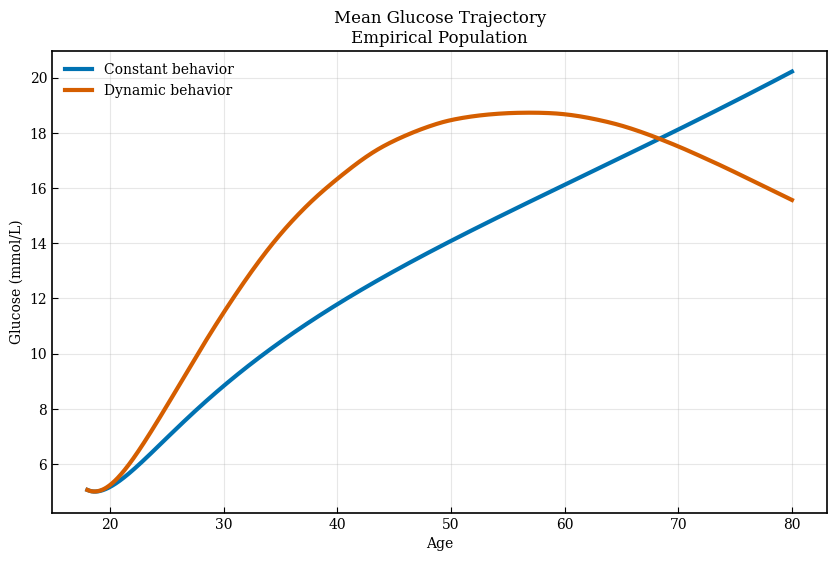

In [ ]:
# =========================================================
# MEAN GLUCOSE TRAJECTORY
# EMPIRICAL POPULATION
# =========================================================

G_const = results[
    ("exp3_empirical", "constant")
][:, :, 0]

G_dyn = results[
    ("exp3_empirical", "dynamic")
][:, :, 0]

# population means

mean_const = G_const.mean(axis=0)

mean_dyn = G_dyn.mean(axis=0)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(

    t_span,
    mean_const,
    linewidth=3,
    color="#0072B2",
    label="Constant behavior"
)

plt.plot(

    t_span,
    mean_dyn,
    linewidth=3,
    color="#D55E00",
    label="Dynamic behavior"
)

plt.xlabel("Age")

plt.ylabel("Glucose (mmol/L)")

plt.title(
    "Mean Glucose Trajectory\n"
    "Empirical Population"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

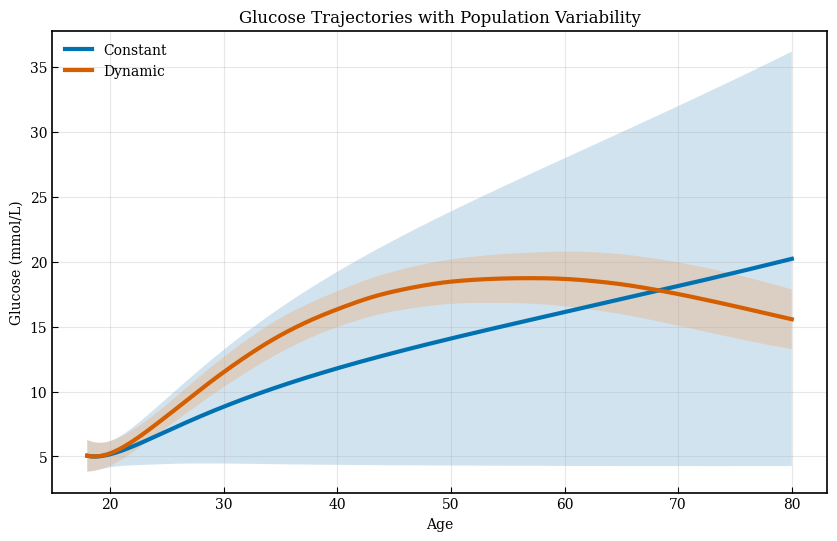

In [ ]:
# =========================================================
# MEAN ± STD GLUCOSE TRAJECTORIES
# =========================================================

G_const = results[
    ("exp3_empirical", "constant")
][:, :, 0]

G_dyn = results[
    ("exp3_empirical", "dynamic")
][:, :, 0]

# means

mean_const = G_const.mean(axis=0)
mean_dyn = G_dyn.mean(axis=0)

# standard deviations

std_const = G_const.std(axis=0)
std_dyn = G_dyn.std(axis=0)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(10, 6))

# constant

plt.plot(

    t_span,
    mean_const,
    linewidth=3,
    color="#0072B2",
    label="Constant"
)

plt.fill_between(

    t_span,

    mean_const - std_const,

    mean_const + std_const,

    alpha=0.2
)

# dynamic

plt.plot(

    t_span,
    mean_dyn,
    linewidth=3,
    color="#D55E00",
    label="Dynamic"
)

plt.fill_between(

    t_span,

    mean_dyn - std_dyn,

    mean_dyn + std_dyn,

    alpha=0.2
)

plt.xlabel("Age")

plt.ylabel("Glucose (mmol/L)")

plt.title(
    "Glucose Trajectories with Population Variability"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

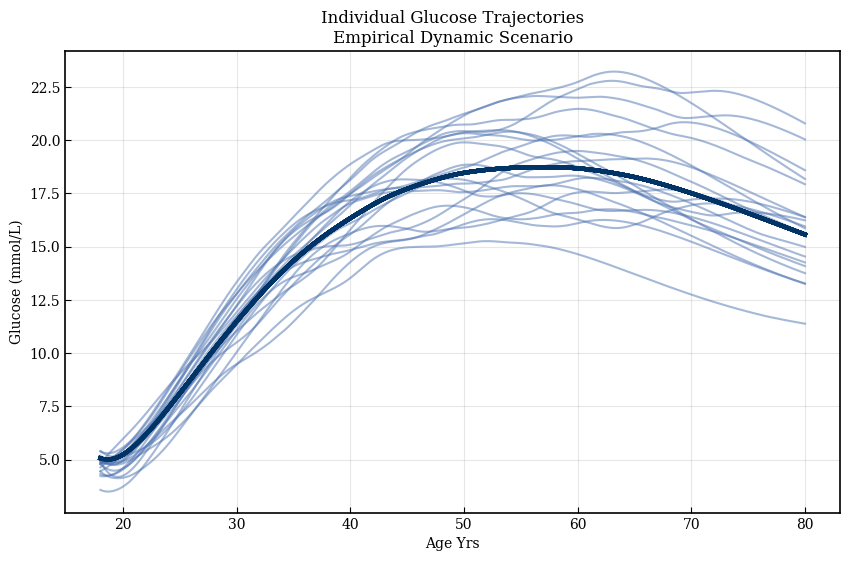

In [ ]:
# =========================================================
# INDIVIDUAL GLUCOSE TRAJECTORIES
# =========================================================

G_dyn = results[
    ("exp3_empirical", "dynamic")
][:, :, 0]

plt.figure(figsize=(10, 6))

# plot first 20 individuals

for i in range(20):

    plt.plot(
        t_span,
        G_dyn[i],
        color="#4C72B0",
        alpha=0.5
    )

    # population mean

    plt.plot(

        t_span,

        mean_dyn,

        color="#003366",
        linewidth=3,
        label="Population mean"
    )

plt.xlabel("Age Yrs")

plt.ylabel("Glucose (mmol/L)")

plt.title(
    "Individual Glucose Trajectories\n"
    "Empirical Dynamic Scenario"
)

plt.grid(alpha=0.3)

plt.show()

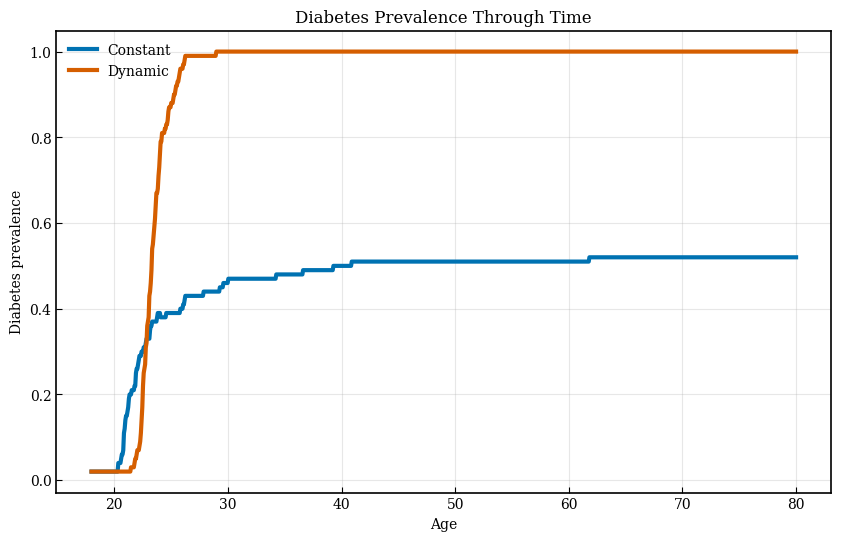

In [ ]:
# =========================================================
# DIABETES PREVALENCE
# =========================================================

threshold = 7.0

G_const = results[
    ("exp3_empirical", "constant")
][:, :, 0]

G_dyn = results[
    ("exp3_empirical", "dynamic")
][:, :, 0]

# prevalence through time

prev_const = (G_const > threshold).mean(axis=0)

prev_dyn = (G_dyn > threshold).mean(axis=0)

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(

    t_span,

    prev_const,

    linewidth=3,
    color="#0072B2",
    label="Constant"
)

plt.plot(

    t_span,
    prev_dyn,
    linewidth=3,
    color="#D55E00",
    label="Dynamic"
)

plt.xlabel("Age")

plt.ylabel("Diabetes prevalence")

plt.title(
    "Diabetes Prevalence Through Time"
)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

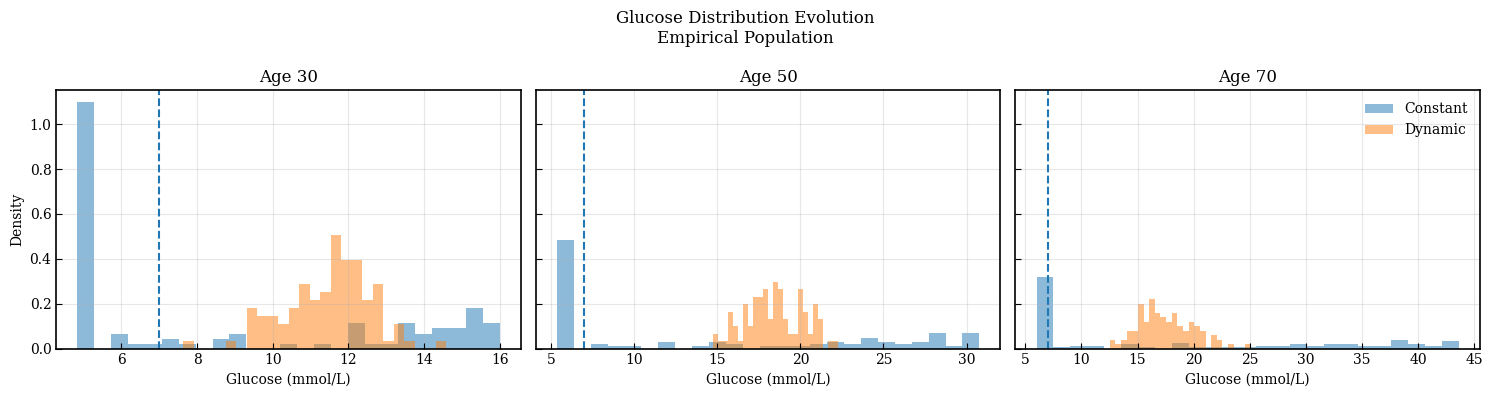

In [ ]:
# =========================================================
# GLUCOSE DISTRIBUTION COMPARISON
# CONSTANT vs DYNAMIC
# =========================================================

ages_to_check = [30, 50, 70]

# empirical experiment

G_const = results[
    ("exp3_empirical", "constant")
][:, :, 0]

G_dyn = results[
    ("exp3_empirical", "dynamic")
][:, :, 0]

# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(

    1,
    len(ages_to_check),

    figsize=(15, 4),

    sharey=True
)

for ax, age in zip(axes, ages_to_check):

    # ---------------------------------------------
    # locate age index
    # ---------------------------------------------

    idx = jnp.argmin(jnp.abs(t_span - age))

    # ---------------------------------------------
    # extract glucose distributions
    # ---------------------------------------------

    Gc = G_const[:, idx]

    Gd = G_dyn[:, idx]

    # ---------------------------------------------
    # histograms
    # ---------------------------------------------

    ax.hist(

        Gc,

        bins=25,

        density=True,

        alpha=0.5,

        label="Constant"
    )

    ax.hist(

        Gd,

        bins=25,

        density=True,

        alpha=0.5,

        label="Dynamic"
    )

    # diabetes threshold

    ax.axvline(

        7.0,

        linestyle="--"
    )

    # labels

    ax.set_title(f"Age {age}")

    ax.set_xlabel("Glucose (mmol/L)")

    ax.grid(alpha=0.3)

# shared ylabel

axes[0].set_ylabel("Density")

# single legend

axes[-1].legend()

plt.suptitle(

    "Glucose Distribution Evolution\n"
    "Empirical Population"
)

plt.tight_layout()

plt.show()

##**Sampling, Simulation, and Likelihood-Based Training**

In [ ]:
def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    #scale = jax.nn.softplus(sigmas) + 1e-3
    scale = 0.1 * jax.nn.softplus(sigmas) + 0.01
    #scale = jax.nn.softplus(sigmas) +1e-3
    return jnp.exp(mus + scale * eps) #OPTION: jnp.exp(mus + 0*scale * eps)
    #return jnp.exp(mus + 0*scale * eps)

def calc_lppd(measurements, mask, sims, sigma):# Computes log predictive probability density
    diffs = sims - measurements[:, None]
    # Clamp differences
    #diffs = jnp.clip(diffs, -20.0, 20.0)
    #sigma = 0.5
    log_coef = -jnp.log(jnp.sqrt(2 * jnp.pi) * sigma)
    log_probs = (log_coef - 0.5 * (diffs / sigma)**2)
    lppd=jnp.nanmean(jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None]))
    #return jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None])
    return lppd


# Time safe indexing
def time_to_index(t, dt):
    return ((t - 18.0) / dt).astype(int)

def init_samples_fn(G0, I0, A0_samples):
    init_samples = jnp.column_stack([
    G0,#OPTION: 5.0*jnp.ones_like(G0),
    jnp.full(N, params_cases["Red"]['B_0']),
    I0,#OPTION: 50.0*jnp.ones_like(I0),
    jnp.full(N, params_cases["Red"]['S_0']),
    jnp.full(N, params_cases["Red"]['L_0']),
    A0_samples])

    return init_samples

def scan_loss_fn(optax_params, glucose, insulin, mask,mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed): #main loss function; training objective
    mus = optax_params["mus"] # extract parameters; learned parameters optimized by optax
    sigmas = optax_params["sigmas"] #extract parameters

    dt=0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # Multivariate reparameterized sampling
    N = eps2_fixed.shape[0]


    L = jnp.linalg.cholesky(cov_jax)

    eps_gi = eps2_fixed

    gi_samples = mean_jax + eps_gi @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = init_samples_fn(G0, I0, A0_samples)

    # parameter samples
    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps_fixed)


    # Scan with inputs
    def simulate_one(param_ind, init_ind, mvpa, calories, key_i):

        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa,
            calories,
            "constant",   # or dynamic
            key_i
        )

        # USE Baseline
        #F_baseline = params_cases["Red"]["F"]
        #Y_baseline = params_cases["Red"]["Y"]

        #F_traj = F_baseline * jnp.ones_like(t_span)
        #Y_traj = Y_baseline * jnp.ones_like(t_span)


        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}
            y_next, _ = ode_rhs_scan(y, t, param_ind, params_step, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))

        return ys

    keys = keys_fixed
    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data, keys)

    # Midpoints
    ages = jnp.array(age_list)

    # convert age → index
    midpoints = ((ages - 18) / (80 - 18) * (states.shape[1] - 1)).astype(int)
    midpoints = jnp.clip(midpoints, 0, states.shape[1] - 1)

    # likelihood
    # ---- glucose likelihood ----
    logexps_glucose = jax.vmap(
        lambda glucose_bin, mask_bin, midpoint:
            calc_lppd(glucose_bin, mask_bin, jnp.log(states[:, midpoint, 0][None, :]+1e-6), sigma=0.1),
        (0, 0, 0)
    )(jnp.log(glucose+1e-6), mask, midpoints)

    # ---- insulin likelihood ----
    logexps_insulin = jax.vmap(
        lambda insulin_bin, mask_bin, midpoint:
            calc_lppd(insulin_bin,mask_bin,jnp.log(states[:, midpoint, 2][None, :] + 1e-6),sigma=0.1),
        (0, 0, 0)
    )(jnp.log(insulin + 1e-6), mask, midpoints)



     # separate means
    mean_glucose = jnp.nanmean(logexps_glucose)
    mean_insulin = jnp.nanmean(logexps_insulin)

    loss = -(mean_glucose/2.0 + mean_insulin/5.0)


    # return loss + aux
    return loss, (logexps_glucose, logexps_insulin, mean_glucose, mean_insulin)

def debug_simulation(optax_params, mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed):

    mus = optax_params["mus"]
    sigmas = optax_params["sigmas"]

    dt = 0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # Multivariate reparameterized sampling
    N = eps2_fixed.shape[0]

    L = jnp.linalg.cholesky(cov_jax)

    eps_gi = eps2_fixed

    gi_samples = mean_jax + eps_gi @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = init_samples_fn(G0, I0, A0_samples)

    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps_fixed)
    #param_samples = jnp.clip(param_samples, 1e-6, None)

    def simulate_one(param_ind, init_ind, mvpa, calories, key_i):

        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa,
            calories,
            "constant",   # or dynamic
            key_i
        )

        # USE Baseline
        #F_baseline = params_cases["Red"]["F"]
        #Y_baseline = params_cases["Red"]["Y"]

        #F_traj = F_baseline * jnp.ones_like(t_span)
        #Y_traj = Y_baseline * jnp.ones_like(t_span)

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}
            y_next, _ = ode_rhs_scan(y, t, param_ind, params_step, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))

        return ys
    # generate keys just like training
    keys = keys_fixed
    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data,keys)

    return t_span, states

## **Data Binning, Parameter Initialization and Training Loop**

In [ ]:
# Set age-list
age_list = list(age_midpoints)

# Build bins
real_bins = {}
insulin_bins = {}

for age in age_list:
    subset = data_filtered[data_filtered["age_bin"] == age]
    subset_clean = subset[["glucose", "insulin"]].dropna()

    g_vals = subset_clean["glucose"].values
    i_vals = subset_clean["insulin"].values

    if len(g_vals) == 0:
        print(f"⚠️ Empty glucose bin at age {age}")

    if len(i_vals) == 0:
        print(f"⚠️ Empty insulin bin at age {age}")

    real_bins[age] = g_vals
    insulin_bins[age] = i_vals

age_list = [age for age in age_list if len(real_bins[age]) > 0]


# Get max_K
max_K = max(len(real_bins[age]) for age in age_list)


# Build arrays and masks
real_array = []
insulin_array = []
mask_array = []

for age in age_list:

    g_vals = real_bins[age]
    i_vals = insulin_bins[age]

    K = len(g_vals)

    # Pad both with same length
    g_padded = np.pad(g_vals, (0, max_K - K), constant_values=0.0)
    i_padded = np.pad(i_vals, (0, max_K - K), constant_values=0.0)

    # Single shared mask
    mask = np.concatenate([np.ones(K), np.zeros(max_K - K)])

    real_array.append(g_padded)
    insulin_array.append(i_padded)
    mask_array.append(mask)


# convert to JAX
real_array = jnp.array(real_array)
insulin_array = jnp.array(insulin_array)
mask_array = jnp.array(mask_array, dtype=bool)


# sanity check
print("real_array shape:", real_array.shape)
print("insulin_array shape:", insulin_array.shape)

for age in age_list:
    print(f"Age {age}: K = {len(real_bins[age])}")


mus = jnp.log(jnp.array([param_dist[k]["mu"] for k in theta_keys]))
#sigmas = jnp.log(jnp.array([param_dist[k]["sigma"] for k in theta_keys]))
sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])

#print(age_list)

#print(real_array[0])

# --- FIXED RANDOMNESS (DO THIS ONCE) ---
key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

eps_fixed  = jax.random.normal(subkey1, shape=(N_samples, 7))
eps2_fixed = jax.random.normal(subkey2, shape=(N_samples, 2))

# keys for behavior / simulation randomness
keys_fixed = jax.random.split(subkey3, N_samples)

optax_params = {"mus":mus,"sigmas":sigmas}

mvpa_data = jnp.clip(vectorized_samples[:, -2], 0.0, 1e4)
calorie_data = jnp.clip(vectorized_samples[:, -1], 0.0, 5000.0)

scan_loss_fn(optax_params,real_array,insulin_array, mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)

optimizer = optax.adam(1e-1)
opt_state = optimizer.init(optax_params)

@jax.jit
def train_step(params, opt_state, real_array, insulin_array,mask_array,mvpa_data, calorie_data, eps_fixed, eps2_fixed, keys_fixed):
    N_samples = 100  # keep small initially

    (loss, aux), grads = jax.value_and_grad(scan_loss_fn, argnums=0, has_aux=True)(params,real_array,insulin_array,mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss,aux

loss_history = []
glucose_history = []
insulin_history = []

resample_every = 1

pbar = tqdm(range(200))

for step in pbar:

    # 🔁 RESAMPLE STOCHASTICITY PERIODICALLY
    if step % resample_every == 0:
        key, k1, k2, k3 = jax.random.split(key, 4)

        eps_fixed  = jax.random.normal(k1, shape=(N_samples, 7))
        eps2_fixed = jax.random.normal(k2, shape=(N_samples, 2))
        keys_fixed = jax.random.split(k3, N_samples)

    # 🔧 TRAIN STEP (UNCHANGED)
    optax_params, opt_state, loss, aux = train_step(
        optax_params,
        opt_state,
        real_array,
        insulin_array,
        mask_array,
        mvpa_data,
        calorie_data,
        eps_fixed,
        eps2_fixed,
        keys_fixed
    )

    # ---- unpack aux ----
    log_g, log_i, mean_g, mean_i = aux

    loss_value = float(loss)
    mean_g_value = float(mean_g)
    mean_i_value = float(mean_i)

    loss_history.append(loss_value)
    glucose_history.append(mean_g_value)
    insulin_history.append(mean_i_value)

    pbar.set_postfix({
        "loss": loss_value,
        "glucose": mean_g_value,
        "insulin": mean_i_value
    })
print(loss)
print(optax_params)

real_array shape: (7, 308)
insulin_array shape: (7, 308)
Age 15: K = 31
Age 25: K = 302
Age 35: K = 308
Age 45: K = 275
Age 55: K = 249
Age 65: K = 307
Age 75: K = 207


100%|██████████| 200/200 [00:42<00:00,  4.73it/s, loss=0.375, glucose=0.0499, insulin=-2]

0.3750167
{'mus': Array([ -6.2872787,  -5.276993 ,  -1.6967813,  -4.0380864,  -9.573267 ,
       -13.294979 , -10.011896 ], dtype=float32), 'sigmas': Array([ 0.1512868 ,  9.590515  ,  8.780975  , -0.96140087, -0.19385938,
       11.595744  ,  0.9369129 ], dtype=float32)}


##**Loss convergence plot**

Saved: lppd_convergence_combined_20260514_020032.png


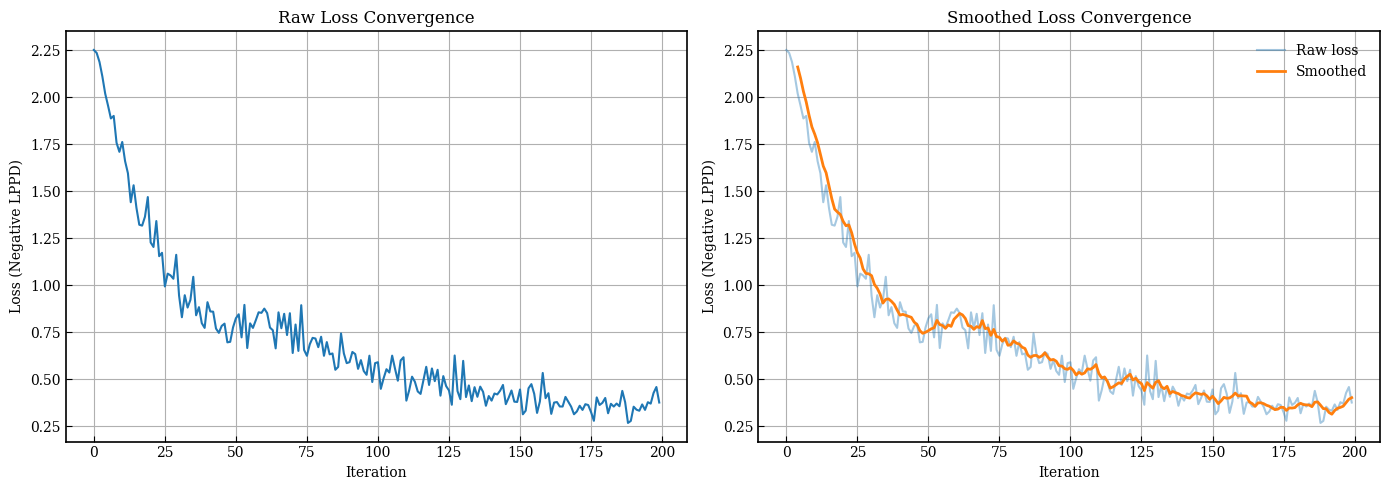

In [ ]:
window = 5
smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT: Raw loss ---
axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss (Negative LPPD)")
axes[0].set_title("Raw Loss Convergence")
axes[0].grid()

# --- RIGHT: Smoothed + raw ---
axes[1].plot(loss_history, alpha=0.4, label="Raw loss")
axes[1].plot(range(window-1, len(loss_history)),
             smoothed_loss,
             linewidth=2,
             label="Smoothed")

axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss (Negative LPPD)")
axes[1].set_title("Smoothed Loss Convergence")
axes[1].legend()
axes[1].grid()

# Layout
plt.tight_layout()

# Save combined figure
save_figure(fig, "lppd_convergence_combined")

plt.show()

In [ ]:
def softplus(x):
    return jnp.log(1 + jnp.exp(x))

mu_vals = optax_params["mus"]
sigma_raw = optax_params["sigmas"]
sigma_eff = softplus(sigma_raw)

print("mu:", mu_vals)
print("sigma_eff:", sigma_eff)

mu: [ -6.2872787  -5.276993   -1.6967813  -4.0380864  -9.573267  -13.294979
 -10.011896 ]
sigma_eff: [ 0.77164876  9.590584    8.781129    0.32378992  0.60090786 11.595754
  1.2675364 ]


In [ ]:
print(optax_params)
#optax_params["mus"] = 0.001*jnp.ones_like(optax_params["mus"])
for i in range(7,):
    print(np.mean(real_array[i][mask_array[i]]))
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))
eps2_fixed = jax.random.normal(subkey, shape=(N_samples, 2))
scan_loss_fn(optax_params,real_array,insulin_array, mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)

{'mus': Array([ -6.2872787,  -5.276993 ,  -1.6967813,  -4.0380864,  -9.573267 ,
       -13.294979 , -10.011896 ], dtype=float32), 'sigmas': Array([ 0.1512868 ,  9.590515  ,  8.780975  , -0.96140087, -0.19385938,
       11.595744  ,  0.9369129 ], dtype=float32)}
4.9855485
5.022298
5.300318
5.709782
6.3046703
6.545052
6.2653713


(Array(0.30999085, dtype=float32),
 (Array([ 0.53826946,  0.3844824 ,  0.13672885,  0.06217663, -0.16096117,
         -0.21706334, -0.23389363], dtype=float32),
  Array([-2.6238465, -2.0219681, -2.231931 , -1.2519513, -1.3214409,
         -1.3712693, -1.3016212], dtype=float32),
  Array(0.0728199, dtype=float32),
  Array(-1.732004, dtype=float32)))

## **Visualization of Model Trajectories and Data Comparison Across Age Bins**

In [ ]:
def plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins,log_plot=True):
    if log_plot:
        states_np = np.log(np.array(states)+1e-6)
    else:
        states_np = np.array(states)
    t_span_np = np.array(t_span)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    # GLUCOSE

    ax = axes[0]

    # --- trajectories ---
    for i in range(states_np.shape[0]):
        ax.plot(t_span_np, states_np[i,:,0], alpha=0.15, color='gray')

    # --- mean + confidence band ---
    mean_G = states_np[:,:,0].mean(axis=0)
    std_G = states_np[:,:,0].std(axis=0)

    ax.plot(t_span_np, mean_G, color='black', linewidth=2, label='Model mean')
    ax.fill_between(t_span_np, mean_G - std_G, mean_G + std_G,
                    color='blue', alpha=0.2, label='Model ±1 std')

    # --- real data ---
    for age in age_list:
        if log_plot:
            vals = np.log(real_bins[age]+1e-6)
        else:
            vals = real_bins[age]
        ax.scatter([age]*len(vals), vals,
                   color='red', alpha=0.15, s=10, label='Data' if age == age_list[0] else "")

    # --- model samples at same ages ---
    for age in age_list:
        idx = np.argmin(np.abs(t_span_np - age))
        model_vals = states_np[:, idx, 0]

        ax.scatter([age]*len(model_vals), model_vals,
                   color='blue', alpha=0.2, s=10,
                   label='Model samples' if age == age_list[0] else "")

    ax.set_title("Glucose: Model vs Data")
    ax.set_xlabel("Age Yrs")
    ax.set_ylabel("Glucose mmol/L")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # INSULIN (LOG SPACE)

    ax = axes[1]

    model_I = states_np[:,:,2]

    # --- trajectories ---
    for i in range(model_I.shape[0]):
        ax.plot(t_span_np, model_I[i], alpha=0.15, color='gray')

    # --- mean + confidence ---
    mean_I = model_I.mean(axis=0)
    std_I = model_I.std(axis=0)

    ax.plot(t_span_np, mean_I, color='black', linewidth=2, label='Model mean')
    ax.fill_between(t_span_np, mean_I - std_I, mean_I + std_I,
                    color='blue', alpha=0.2, label='Model ±1 std')

    # --- real data ---
    for age in age_list:
        vals = insulin_bins[age]
        if log_plot:
            data_I = np.log(vals + 1e-6)
        else:
            data_I = vals

        ax.scatter([age]*len(data_I), data_I,
                   color='red', alpha=0.25, s=10,
                   label='Data' if age == age_list[0] else "")

    # --- model samples at same ages ---
    for age in age_list:
        idx = np.argmin(np.abs(t_span_np - age))
        model_vals = states_np[:, idx, 2]

        ax.scatter([age]*len(model_vals), model_vals,
                   color='blue', alpha=0.25, s=10,
                   label='Model samples' if age == age_list[0] else "")

    ax.set_title("Insulin (log): Model vs Data")
    ax.set_xlabel("Age Yrs")
    ax.set_ylabel("log(Insulin) pmol/L")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # =========================
    plt.suptitle("Model Behavior vs Real Data", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "Model Behavior vs Real Data")
    plt.show()


#def plot_all_states(states, t_span):

    #states_np = np.array(states)
    #t_span_np = np.array(t_span)

    #labels = ["Glucose (G)", "Beta cells (B)", "Insulin (I)", "Sensitivity (S)", "Liver (L)"]

    #fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    #axes = axes.flatten()

    #for i in range(5):
        #ax = axes[i]

        # trajectories
        #for j in range(states_np.shape[0]):
            #ax.plot(t_span_np, states_np[j,:,i], alpha=0.2)

        # mean
        #mean_traj = states_np[:,:,i].mean(axis=0)
        #ax.plot(t_span_np, mean_traj, linewidth=2)

        #ax.set_title(labels[i])
        #ax.set_xlabel("Age Yrs")
        #ax.set_ylabel("Value")
        #ax.grid(True, alpha=0.3)

    #fig.delaxes(axes[5])

    #plt.suptitle("Simulated Physiological Trajectories", fontsize=16)
    #plt.tight_layout()
    #save_figure(fig, "Simulated Physiological Trajectories")
    #plt.show()

def plot_all_states(states, t_span):

    # -------------------------------------------------------------------------
    # CONVERT TO NUMPY
    # -------------------------------------------------------------------------
    states_np = np.array(states)
    t_span_np = np.array(t_span)

    # -------------------------------------------------------------------------
    # LABELS + UNITS + AXIS LIMITS
    # -------------------------------------------------------------------------
    state_info = [
        {
            "title": r"Glucose $G(t)$",
            "ylabel": r"$G(t)$ [mmol/L]",
            "ylim": (0, 30)
        },
        {
            "title": r"Beta cells $B(t)$",
            "ylabel": r"$B(t)$ [$10^9$ cells]",
            "ylim": (0, 1300)
        },
        {
            "title": r"Insulin $I(t)$",
            "ylabel": r"$I(t)$ [pmol/L]",
            "ylim": (0, 250)
        },
        {
            "title": r"Sensitivity $S(t)$",
            "ylabel": r"$S(t)$ [L/yr/pM]",
            "ylim": (0, 0.06)
        },
        {
            "title": r"Liver $L(t)$",
            "ylabel": r"$L(t)$ [mM/pM]",
            "ylim": (0, 0.035)
        }
    ]

    # -------------------------------------------------------------------------
    # CREATE FIGURE
    # -------------------------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    axes = axes.flatten()

    # -------------------------------------------------------------------------
    # LOOP THROUGH STATES
    # -------------------------------------------------------------------------
    for i in range(5):

        ax = axes[i]

        # ---------------------------------------------------------------------
        # INDIVIDUAL TRAJECTORIES
        # ---------------------------------------------------------------------
        for j in range(states_np.shape[0]):

            ax.plot(
                t_span_np,
                states_np[j, :, i],
                alpha=0.15
            )

        # ---------------------------------------------------------------------
        # MEAN TRAJECTORY
        # ---------------------------------------------------------------------
        mean_traj = states_np[:, :, i].mean(axis=0)

        ax.plot(
            t_span_np,
            mean_traj,
            color='black',
            linewidth=2.5,
            label='Mean'
        )

        # ---------------------------------------------------------------------
        # CONFIDENCE BAND
        # ---------------------------------------------------------------------
        lower = np.percentile(states_np[:, :, i], 5, axis=0)

        upper = np.percentile(states_np[:, :, i], 95, axis=0)

        ax.fill_between(
            t_span_np,
            lower,
            upper,
            alpha=0.2,
            label='5–95 percentile'
        )

        # ---------------------------------------------------------------------
        # LABELS
        # ---------------------------------------------------------------------
        ax.set_title(
            state_info[i]["title"],
            fontsize=13
        )

        ax.set_xlabel(
            r"$t$ [yr]",
            fontsize=11
        )

        ax.set_ylabel(
            state_info[i]["ylabel"],
            fontsize=11
        )

        # ---------------------------------------------------------------------
        # AXIS LIMITS
        # ---------------------------------------------------------------------
        ax.set_xlim(
            t_span_np[0],
            t_span_np[-1]
        )

        ax.set_ylim(
            state_info[i]["ylim"]
        )

        # ---------------------------------------------------------------------
        # GRID
        # ---------------------------------------------------------------------
        ax.grid(True, alpha=0.3)

        ax.legend(fontsize=9)

    # -------------------------------------------------------------------------
    # REMOVE EMPTY PANEL
    # -------------------------------------------------------------------------
    fig.delaxes(axes[5])

    # -------------------------------------------------------------------------
    # TITLE
    # -------------------------------------------------------------------------
    plt.suptitle(
        "Simulated Physiological Trajectories",
        fontsize=16
    )

    plt.tight_layout()

    save_figure(
        fig,
        "Simulated Physiological Trajectories"
    )

    plt.show()

In [ ]:
print(params_cases['Red'])

{'t0': 0, 'tend': 50, 't_delta': 0.1, 'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0, 'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144, 'k_max_G': 1.00948, 'G_0': 5.0, 'lambda_BA': 0.005, 'k_OB_G': 0.001, 'k_B': 5.0, 'B0_N': 1000.0, 'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0, 'k_S': 1e-05, 'k_SY': 1e-09, 'k_OS': 0.01, 'k_OSF': 0.001, 'k_OSA': 0.0005, 'S_0': 0.001, 'k_L': 0.0001, 'k_LY': 2e-09, 'k_OL': 0.01, 'k_OLF': 0.001, 'k_OLA': 0.0005, 'L_0': 0.01, 's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144, 'F': 500.0, 'Y': 0.0, 'A0': 18.0}


[999.6871  999.3747  999.0625  ... 415.4198  415.38895 415.358  ]
Saved: Model Behavior vs Real Data_20260514_020057.png


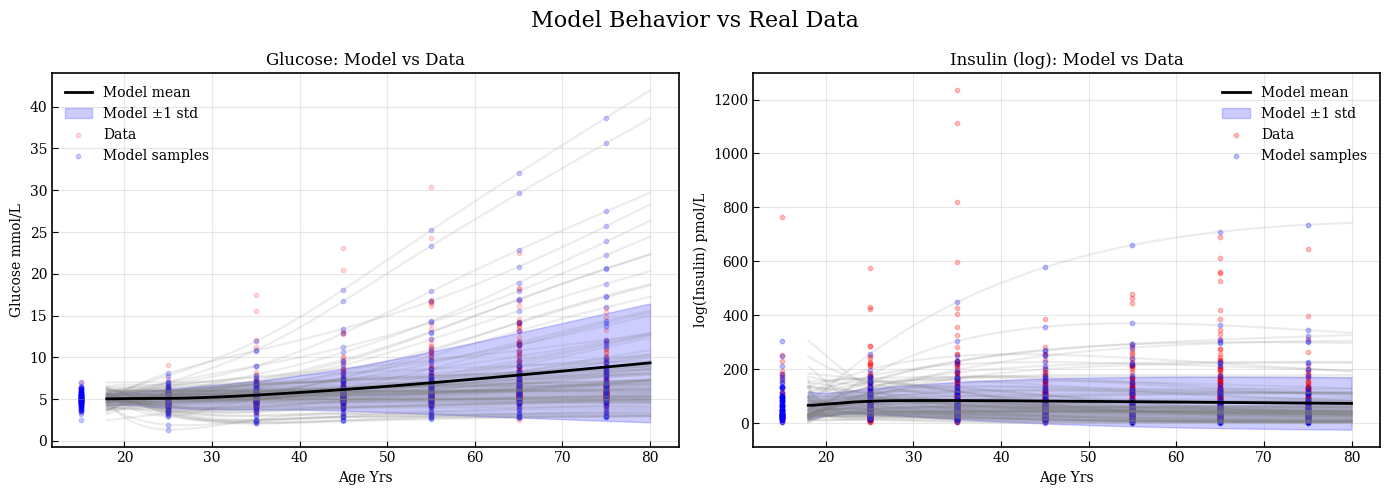

Saved: Simulated Physiological Trajectories_20260514_020103.png


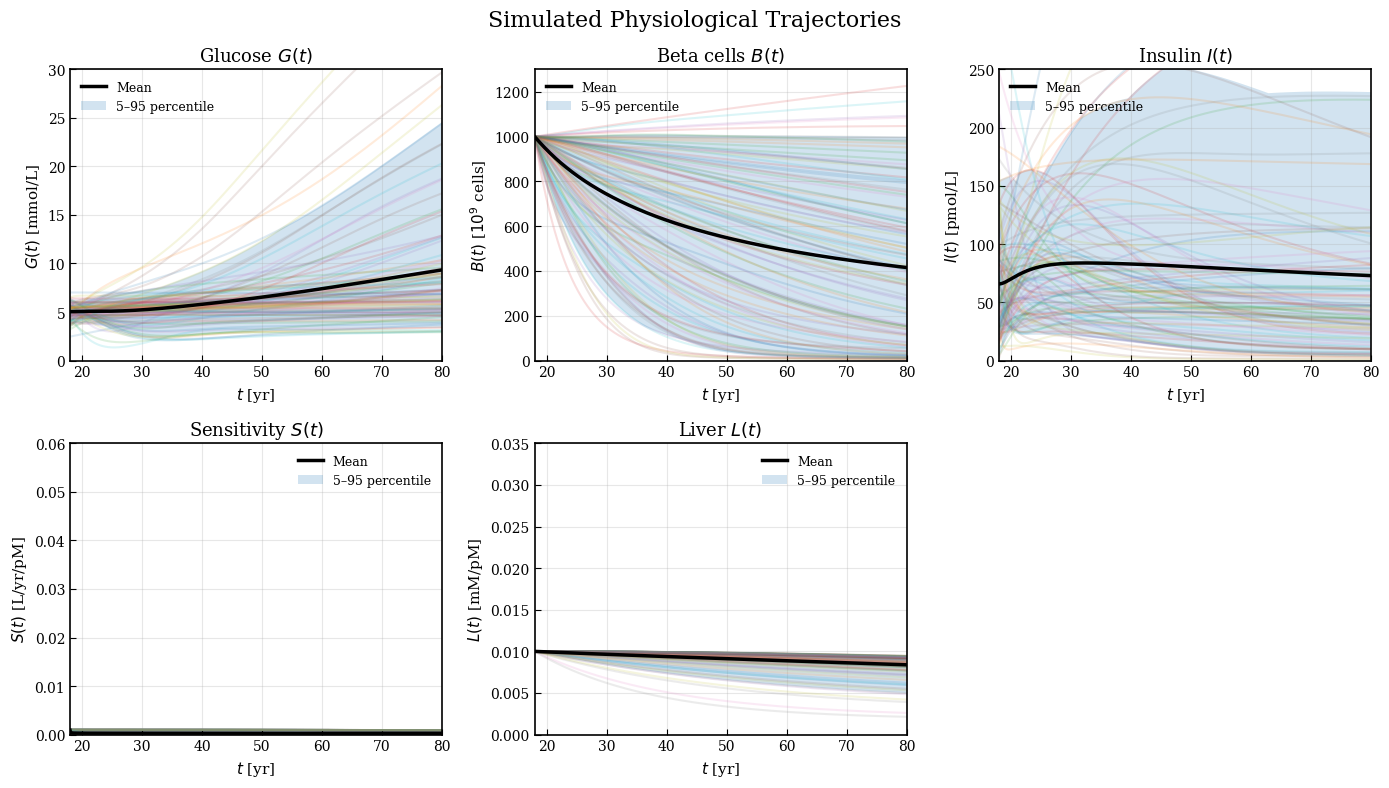

In [ ]:
# --- regenerate noise
key, subkey1, subkey2 = jax.random.split(key, 3)

eps  = jax.random.normal(subkey1, shape=(N_samples, 7))
eps2 = jax.random.normal(subkey2, shape=(N_samples, 2))

# --- simulate ---
t_span, states = debug_simulation(optax_params, mvpa_data, calorie_data, eps, eps2,keys_fixed)
print(states[:,:,1].mean(0))
# --- plot ---
plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins, False)
plot_all_states(states, t_span)

In [ ]:
print("Raw glucose stats:")
print("Min:", data_filtered["glucose"].min())
print("Max:", data_filtered["glucose"].max())

print("\nQuantiles:")
print(data_filtered["glucose"].quantile([0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0]))

high_vals = data_filtered[data_filtered["glucose"] > 15]

print("Number of glucose > 15:", len(high_vals))
print("Percentage:", len(high_vals) / len(data_filtered) * 100)

print(high_vals[["age", "glucose"]].head(20))

Raw glucose stats:
Min: 2.537
Max: 30.397

Quantiles:
0.00     2.53700
0.01     3.76174
0.05     4.39100
0.50     5.33500
0.95     9.00410
0.99    15.46874
1.00    30.39700
Name: glucose, dtype: float64
Number of glucose > 15: 18
Percentage: 1.0720667063728408
       age  glucose
266   45.0   23.092
632   43.0   20.417
999   61.0   18.235
1599  61.0   16.792
1616  37.0   15.521
2240  55.0   16.831
4242  51.0   30.397
4883  55.0   24.297
6009  63.0   22.532
7078  58.0   16.187
7635  74.0   15.909
7697  36.0   17.458
8170  52.0   16.597
8773  52.0   16.775
8940  64.0   16.098
9160  51.0   16.475
9281  76.0   15.454
9327  68.0   18.274


Saved: distribution_comparison_age_45_20260514_020207.png


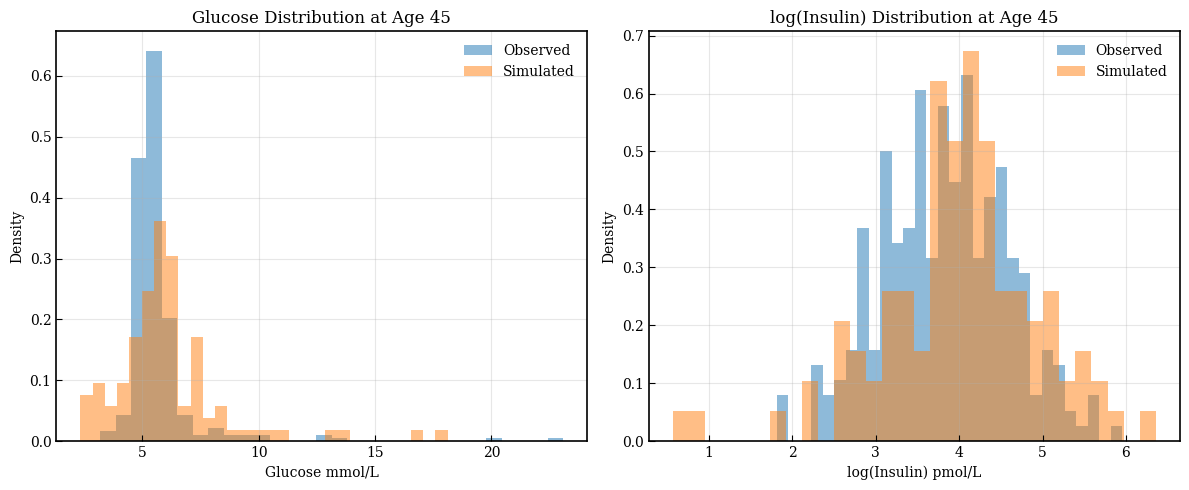

In [ ]:
def plot_distribution_comparison(states, t_span, age_list, real_bins, insulin_bins, age_target):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    # find closest index to chosen age
    idx = np.argmin(np.abs(t_span_np - age_target))

    # get data
    real_g = real_bins[age_target]
    sim_g  = states_np[:, idx, 0]

    real_i = np.log(insulin_bins[age_target] + 1e-6)
    sim_i  = np.log(states_np[:, idx, 2] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- GLUCOSE ---
    axes[0].hist(real_g, bins=30, alpha=0.5, density=True, label="Observed")
    axes[0].hist(sim_g,  bins=30, alpha=0.5, density=True, label="Simulated")

    axes[0].set_title(f"Glucose Distribution at Age {age_target}")
    axes[0].set_xlabel("Glucose mmol/L")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- INSULIN (LOG) ---
    axes[1].hist(real_i, bins=30, alpha=0.5, density=True, label="Observed")
    axes[1].hist(sim_i,  bins=30, alpha=0.5, density=True, label="Simulated")

    axes[1].set_title(f"log(Insulin) Distribution at Age {age_target}")
    axes[1].set_xlabel("log(Insulin) pmol/L")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f"distribution_comparison_age_{age_target}")
    plt.show()

plot_distribution_comparison(
    states,
    t_span,
    age_list,
    real_bins,
    insulin_bins,
    age_target=45   #
)

In [ ]:
print("t_span shape:", t_span.shape)
print("G_const[i] shape:", G_const[i].shape)

t_span shape: (6201,)
G_const[i] shape: (1000,)


Valid constant trajectories: 100
Valid dynamic trajectories: 100
Saved: behavioral_impact_empirical_population_20260514_020224.png


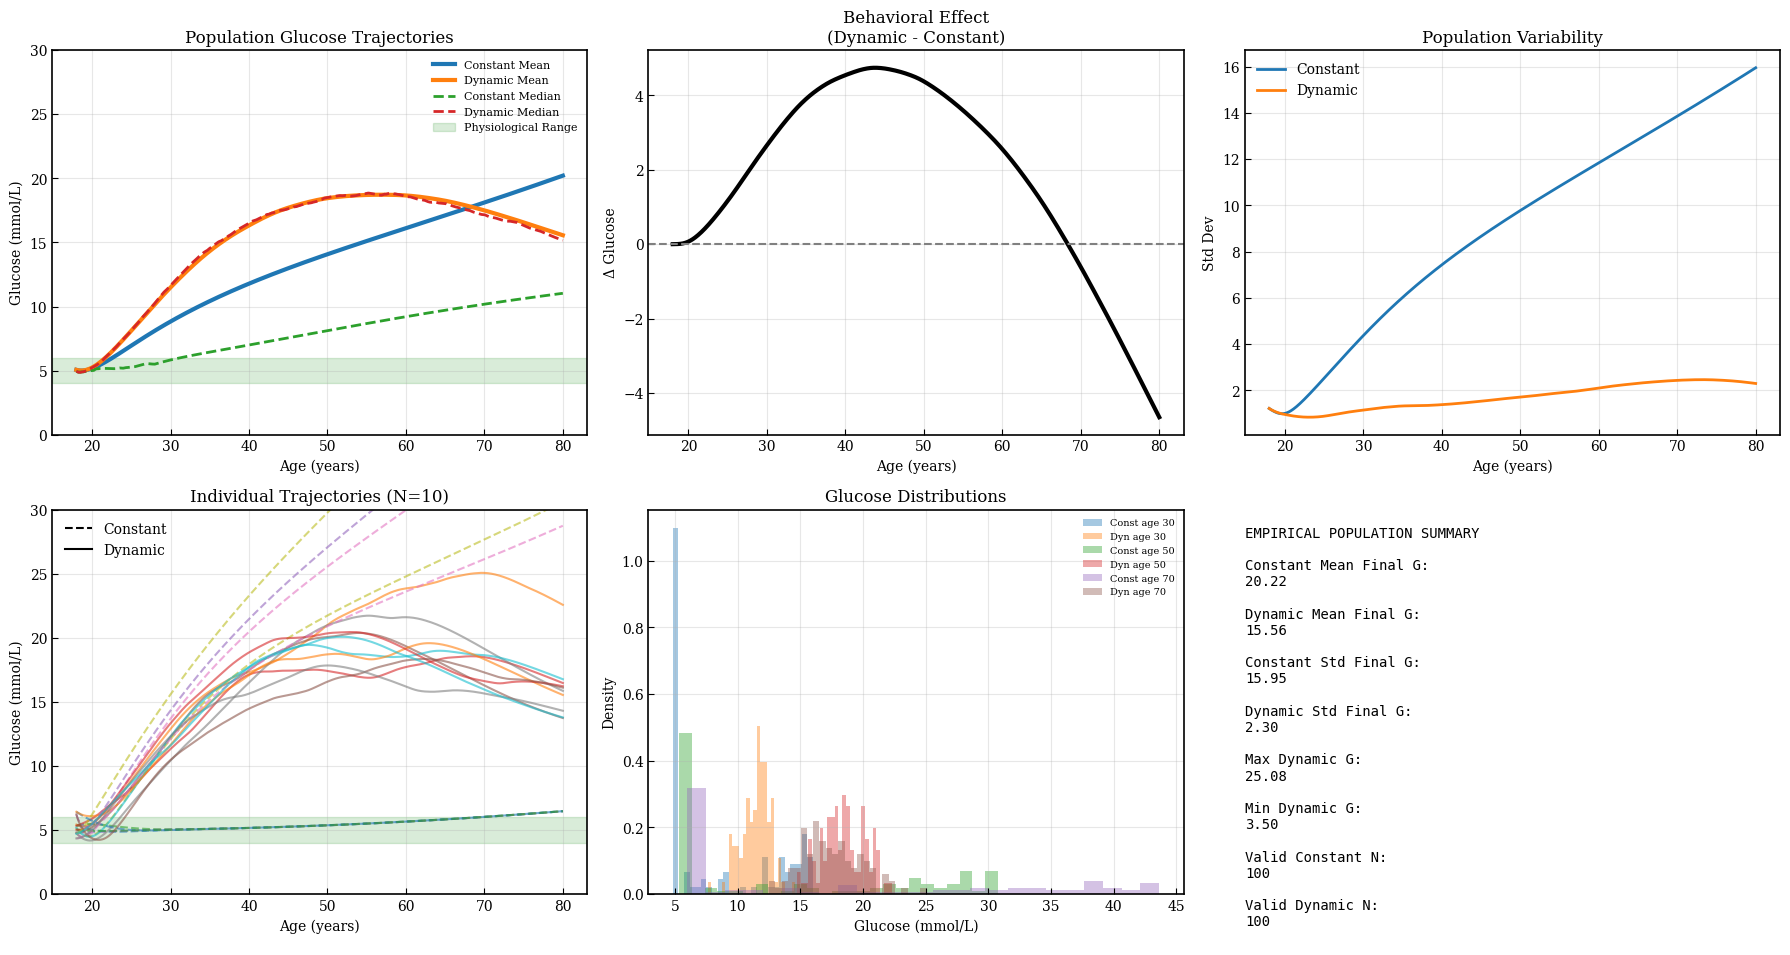

In [ ]:
# =============================================================================
# COMBINED GLUCOSE ANALYSIS FIGURE
# =============================================================================

# use the SAME t_span as simulation
t_axis = np.linspace(
    18,
    80,
    G_const.shape[1]
)

# =============================================================================
# EXTRACT EMPIRICAL RESULTS
# =============================================================================

G_const = np.array(
    results[("exp3_empirical", "constant")][:, :, 0]
)

G_dyn = np.array(
    results[("exp3_empirical", "dynamic")][:, :, 0]
)

# =============================================================================
# OPTIONAL PHYSIOLOGICAL FILTERING
# Remove impossible glucose trajectories
# =============================================================================

#valid_const = (
    #np.isfinite(G_const).all(axis=1)
    #& (G_const > 0).all(axis=1)
    #& (G_const < 30).all(axis=1)
#)

#valid_dyn = (
    #np.isfinite(G_dyn).all(axis=1)
    #& (G_dyn > 0).all(axis=1)
    #& (G_dyn < 30).all(axis=1)
#)

#G_const = G_const[valid_const]
#G_dyn = G_dyn[valid_dyn]

G_const = G_const
G_dyn = G_dyn

print("Valid constant trajectories:", G_const.shape[0])
print("Valid dynamic trajectories:", G_dyn.shape[0])

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

mean_const = G_const.mean(axis=0)
mean_dyn   = G_dyn.mean(axis=0)

std_const = G_const.std(axis=0)
std_dyn   = G_dyn.std(axis=0)

median_const = np.median(G_const, axis=0)
median_dyn   = np.median(G_dyn, axis=0)

diff = mean_dyn - mean_const

# =============================================================================
# HISTOGRAM SNAPSHOT AGES
# =============================================================================

ages_to_check = [30, 50, 70]

indices = [
    np.argmin(np.abs(t_axis - age))
    for age in ages_to_check
]

# =============================================================================
# RANDOM INDIVIDUALS
# =============================================================================

np.random.seed(0)

n_plot = min(10, G_const.shape[0])

indices_individuals = np.random.choice(
    G_const.shape[0],
    size=n_plot,
    replace=False
)

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# =============================================================================
# (1) MEAN + MEDIAN TRAJECTORIES
# =============================================================================

ax = axes[0, 0]

ax.plot(
    t_axis,
    mean_const,
    linewidth=3,
    label="Constant Mean"
)

ax.plot(
    t_axis,
    mean_dyn,
    linewidth=3,
    label="Dynamic Mean"
)

ax.plot(
    t_axis,
    median_const,
    linestyle='--',
    linewidth=2,
    label="Constant Median"
)

ax.plot(
    t_axis,
    median_dyn,
    linestyle='--',
    linewidth=2,
    label="Dynamic Median"
)

# physiological glucose range
ax.axhspan(
    4.0,
    6.0,
    alpha=0.15,
    color='green',
    label='Physiological Range'
)

ax.set_title("Population Glucose Trajectories")

ax.set_xlabel("Age (years)")

ax.set_ylabel("Glucose (mmol/L)")

ax.set_ylim(0, 30)

ax.legend(fontsize=8)

ax.grid(alpha=0.3)

# =============================================================================
# (2) DYNAMIC - CONSTANT DIFFERENCE
# =============================================================================

ax = axes[0, 1]

ax.plot(
    t_axis,
    diff,
    color='black',
    linewidth=3
)

ax.axhline(
    0,
    linestyle='--',
    color='gray'
)

ax.set_title("Behavioral Effect\n(Dynamic - Constant)")

ax.set_xlabel("Age (years)")

ax.set_ylabel("Δ Glucose")

ax.grid(alpha=0.3)

# =============================================================================
# (3) VARIABILITY
# =============================================================================

ax = axes[0, 2]

ax.plot(
    t_axis,
    std_const,
    linewidth=2,
    label="Constant"
)

ax.plot(
    t_axis,
    std_dyn,
    linewidth=2,
    label="Dynamic"
)

ax.set_title("Population Variability")

ax.set_xlabel("Age (years)")

ax.set_ylabel("Std Dev")

ax.legend()

ax.grid(alpha=0.3)

# =============================================================================
# (4) INDIVIDUAL TRAJECTORIES
# =============================================================================

ax = axes[1, 0]

for idx in indices_individuals:

    ax.plot(
        t_axis,
        G_const[idx],
        linestyle='--',
        alpha=0.6
    )

    ax.plot(
        t_axis,
        G_dyn[idx],
        linestyle='-',
        alpha=0.6
    )

ax.axhspan(
    4.0,
    6.0,
    alpha=0.15,
    color='green'
)

ax.set_title("Individual Trajectories (N=10)")

ax.set_xlabel("Age (years)")

ax.set_ylabel("Glucose (mmol/L)")

ax.set_ylim(0, 30)

# legend proxy
ax.plot([], [], '--', color='black', label='Constant')
ax.plot([], [], '-', color='black', label='Dynamic')

ax.legend()

ax.grid(alpha=0.3)

# =============================================================================
# (5) DISTRIBUTION SNAPSHOTS
# =============================================================================

ax = axes[1, 1]

for idx, age in zip(indices, ages_to_check):

    ax.hist(
        G_const[:, idx],
        bins=25,
        alpha=0.4,
        density=True,
        label=f"Const age {age}"
    )

    ax.hist(
        G_dyn[:, idx],
        bins=25,
        alpha=0.4,
        density=True,
        label=f"Dyn age {age}"
    )

ax.set_title("Glucose Distributions")

ax.set_xlabel("Glucose (mmol/L)")

ax.set_ylabel("Density")

ax.legend(fontsize=7)

ax.grid(alpha=0.3)

# =============================================================================
# (6) PHYSIOLOGICAL SUMMARY PANEL
# =============================================================================

ax = axes[1, 2]

ax.axis('off')

summary_text = f"""
EMPIRICAL POPULATION SUMMARY

Constant Mean Final G:
{mean_const[-1]:.2f}

Dynamic Mean Final G:
{mean_dyn[-1]:.2f}

Constant Std Final G:
{std_const[-1]:.2f}

Dynamic Std Final G:
{std_dyn[-1]:.2f}

Max Dynamic G:
{G_dyn.max():.2f}

Min Dynamic G:
{G_dyn.min():.2f}

Valid Constant N:
{G_const.shape[0]}

Valid Dynamic N:
{G_dyn.shape[0]}
"""

ax.text(
    0.0,
    1.0,
    summary_text,
    fontsize=10,
    va='top',
    family='monospace'
)

# =============================================================================
# LAYOUT
# =============================================================================

plt.tight_layout()

save_figure(
    fig,
    "behavioral_impact_empirical_population"
)

plt.show()

Valid empirical constant: 67
Valid distribution constant: 51
Valid empirical dynamic: 100
Valid distribution dynamic: 100
Saved: initial_state_sensitivity_updated_20260514_020237.png


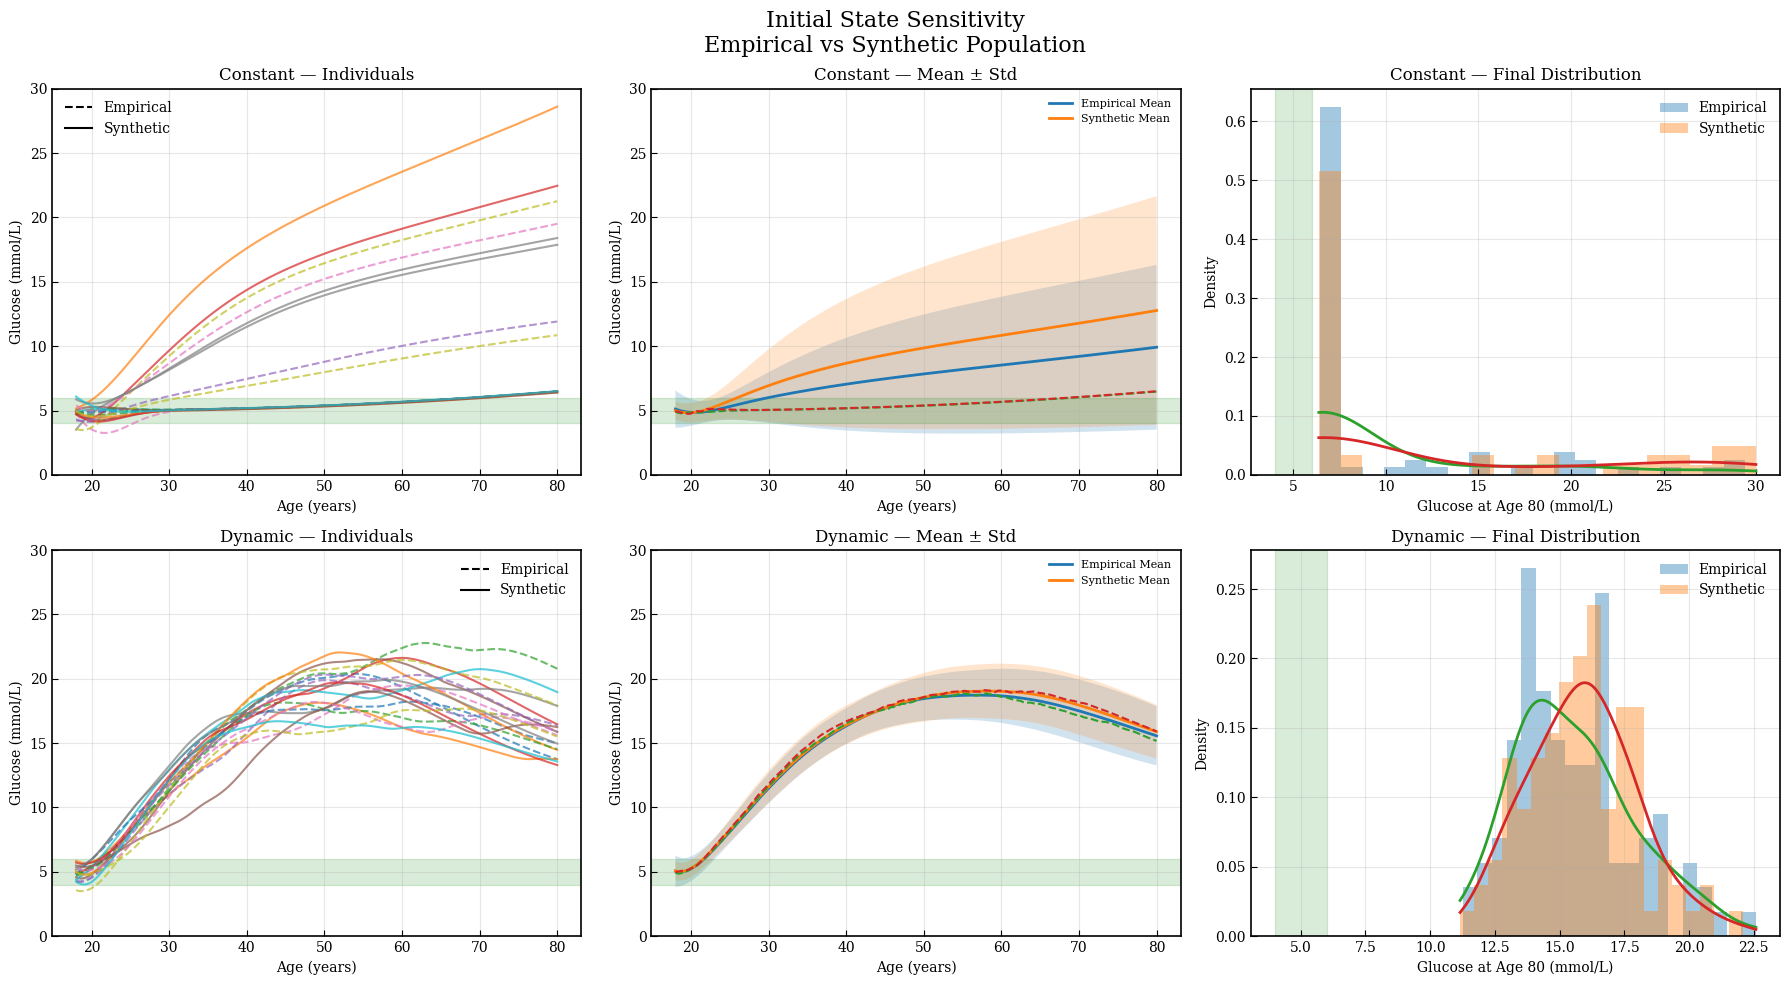

In [ ]:
# =============================================================================
# INITIAL STATE SENSITIVITY
# EMPIRICAL vs SYNTHETIC DISTRIBUTION
# CONSTANT vs DYNAMIC BEHAVIOR
# Updated for corrected simulation framework
# =============================================================================
import scipy.stats as stats
# =============================================================================
# EXTRACT RESULTS
# =============================================================================

G_emp_const = np.array(
    results[("exp3_empirical", "constant")][:, :, 0]
)

G_dist_const = np.array(
    results[("exp2_heterogeneous", "constant")][:, :, 0]
)

G_emp_dyn = np.array(
    results[("exp3_empirical", "dynamic")][:, :, 0]
)

G_dist_dyn = np.array(
    results[("exp2_heterogeneous", "dynamic")][:, :, 0]
)

# =============================================================================
# PHYSIOLOGICAL FILTERING
# =============================================================================

def valid_mask(G):

    return (
        np.isfinite(G).all(axis=1)
        & (G > 0).all(axis=1)
        & (G < 30).all(axis=1)
    )

mask_emp_const = valid_mask(G_emp_const)
mask_dist_const = valid_mask(G_dist_const)

mask_emp_dyn = valid_mask(G_emp_dyn)
mask_dist_dyn = valid_mask(G_dist_dyn)

G_emp_const = G_emp_const[mask_emp_const]
G_dist_const = G_dist_const[mask_dist_const]

G_emp_dyn = G_emp_dyn[mask_emp_dyn]
G_dist_dyn = G_dist_dyn[mask_dist_dyn]

print("Valid empirical constant:", G_emp_const.shape[0])
print("Valid distribution constant:", G_dist_const.shape[0])

print("Valid empirical dynamic:", G_emp_dyn.shape[0])
print("Valid distribution dynamic:", G_dist_dyn.shape[0])

# =============================================================================
# TIME AXIS
# =============================================================================

t_axis = np.linspace(
    18,
    80,
    G_emp_const.shape[1]
)

# =============================================================================
# FINAL DISTRIBUTIONS
# =============================================================================

G_final_emp_const = G_emp_const[:, -1]
G_final_dist_const = G_dist_const[:, -1]

G_final_emp_dyn = G_emp_dyn[:, -1]
G_final_dist_dyn = G_dist_dyn[:, -1]

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

modes = ["constant", "dynamic"]

for row, behavior_mode in enumerate(modes):

    # =========================================================================
    # SELECT DATA
    # =========================================================================

    if behavior_mode == "constant":

        G_emp = G_emp_const
        G_dist = G_dist_const

        G_emp_final = G_final_emp_const
        G_dist_final = G_final_dist_const

    else:

        G_emp = G_emp_dyn
        G_dist = G_dist_dyn

        G_emp_final = G_final_emp_dyn
        G_dist_final = G_final_dist_dyn

    # =========================================================================
    # SUMMARY STATISTICS
    # =========================================================================

    mean_G_emp = G_emp.mean(axis=0)
    std_G_emp = G_emp.std(axis=0)

    mean_G_dist = G_dist.mean(axis=0)
    std_G_dist = G_dist.std(axis=0)

    median_G_emp = np.median(G_emp, axis=0)
    median_G_dist = np.median(G_dist, axis=0)

    # =========================================================================
    # SAME INDIVIDUALS
    # =========================================================================

    np.random.seed(0)

    n_subset = min(
        10,
        G_emp.shape[0],
        G_dist.shape[0]
    )

    idx_subset = np.random.choice(
        n_subset,
        size=n_subset,
        replace=False
    )

    # =========================================================================
    # LEFT PANEL — INDIVIDUAL TRAJECTORIES
    # =========================================================================

    ax = axes[row, 0]

    for i in idx_subset:

        ax.plot(
            t_axis,
            G_emp[i],
            '--',
            alpha=0.7
        )

        ax.plot(
            t_axis,
            G_dist[i],
            '-',
            alpha=0.7
        )

    # physiological range
    ax.axhspan(
        4.0,
        6.0,
        alpha=0.15,
        color='green'
    )

    ax.set_title(
        f"{behavior_mode.capitalize()} — Individuals"
    )

    ax.set_xlabel("Age (years)")

    ax.set_ylabel("Glucose (mmol/L)")

    ax.set_ylim(0, 30)

    # legend proxy
    ax.plot([], [], '--', color='black', label='Empirical')
    ax.plot([], [], '-', color='black', label='Synthetic')

    ax.legend()

    ax.grid(True, alpha=0.3)

    # =========================================================================
    # MIDDLE PANEL — MEAN ± STD
    # =========================================================================

    ax = axes[row, 1]

    ax.plot(
        t_axis,
        mean_G_emp,
        linewidth=2,
        label="Empirical Mean"
    )

    ax.fill_between(
        t_axis,
        mean_G_emp - std_G_emp,
        mean_G_emp + std_G_emp,
        alpha=0.2
    )

    ax.plot(
        t_axis,
        mean_G_dist,
        linewidth=2,
        label="Synthetic Mean"
    )

    ax.fill_between(
        t_axis,
        mean_G_dist - std_G_dist,
        mean_G_dist + std_G_dist,
        alpha=0.2
    )

    # median curves
    ax.plot(
        t_axis,
        median_G_emp,
        linestyle='--',
        linewidth=1.5
    )

    ax.plot(
        t_axis,
        median_G_dist,
        linestyle='--',
        linewidth=1.5
    )

    # physiological range
    ax.axhspan(
        4.0,
        6.0,
        alpha=0.15,
        color='green'
    )

    ax.set_title(
        f"{behavior_mode.capitalize()} — Mean ± Std"
    )

    ax.set_xlabel("Age (years)")

    ax.set_ylabel("Glucose (mmol/L)")

    ax.set_ylim(0, 30)

    ax.legend(fontsize=8)

    ax.grid(True, alpha=0.3)

    # =========================================================================
    # RIGHT PANEL — FINAL DISTRIBUTION
    # =========================================================================

    ax = axes[row, 2]

    ax.hist(
        G_emp_final,
        bins=20,
        density=True,
        alpha=0.4,
        label="Empirical"
    )

    ax.hist(
        G_dist_final,
        bins=20,
        density=True,
        alpha=0.4,
        label="Synthetic"
    )

    # KDE support
    xmin = min(
        G_emp_final.min(),
        G_dist_final.min()
    )

    xmax = max(
        G_emp_final.max(),
        G_dist_final.max()
    )

    x = np.linspace(xmin, xmax, 200)

    # KDE curves
    kde_emp = stats.gaussian_kde(G_emp_final)
    kde_dist = stats.gaussian_kde(G_dist_final)

    ax.plot(
        x,
        kde_emp(x),
        linewidth=2
    )

    ax.plot(
        x,
        kde_dist(x),
        linewidth=2
    )

    # physiological region
    ax.axvspan(
        4.0,
        6.0,
        alpha=0.15,
        color='green'
    )

    ax.set_title(
        f"{behavior_mode.capitalize()} — Final Distribution"
    )

    ax.set_xlabel("Glucose at Age 80 (mmol/L)")

    ax.set_ylabel("Density")

    ax.legend()

    ax.grid(True, alpha=0.3)

# =============================================================================
# GLOBAL TITLE
# =============================================================================

plt.suptitle(
    "Initial State Sensitivity\nEmpirical vs Synthetic Population",
    fontsize=16
)

# =============================================================================
# LAYOUT
# =============================================================================

plt.tight_layout()

save_figure(
    fig,
    "initial_state_sensitivity_updated"
)

plt.show()

constant -> (100, 6201, 6)
dynamic -> (100, 6201, 6)
Valid constant trajectories: 100
Valid dynamic trajectories: 100
Saved: behavioral_input_sensitivity_updated_20260514_020252.png


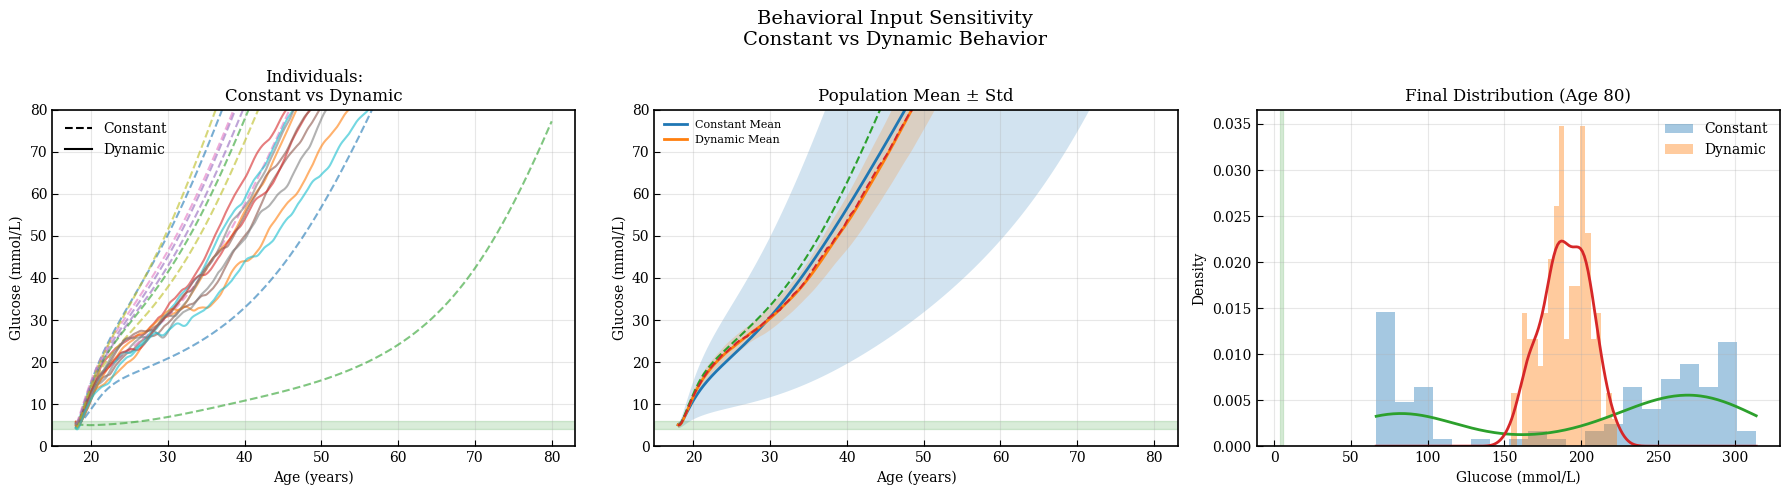

In [ ]:
# =============================================================================
# BEHAVIORAL INPUT SENSITIVITY
# CONSTANT vs DYNAMIC BEHAVIOR
# Updated for corrected simulation framework
# =============================================================================

import scipy.stats as stats

# =============================================================================
# RUN POPULATION SIMULATIONS
# =============================================================================
# use the SAME t_span as simulation

results_behavior = {}

for behavior_mode in ["constant", "dynamic"]:

    key, subkey = jax.random.split(key)

    states = simulate_population(

        # synthetic heterogeneous population
        init_states=init_distribution,

        # SAME baseline behavioral population
        mvpa0=mvpa_distribution,
        cal0=calorie_distribution,

        behavior_mode=behavior_mode,

        # heterogeneous physiology
        heterogeneous_params=True,

        key=subkey
    )

    results_behavior[behavior_mode] = states

    print(f"{behavior_mode} -> {states.shape}")

# =============================================================================
# EXTRACT GLUCOSE
# =============================================================================

G_const = np.array(
    results_behavior["constant"][:, :, 0]
)

G_dyn = np.array(
    results_behavior["dynamic"][:, :, 0]
)

# =============================================================================
# PHYSIOLOGICAL FILTERING
# =============================================================================

#valid_const = (
    #np.isfinite(G_const).all(axis=1)
    #& (G_const > 0).all(axis=1)
    #& (G_const < 30).all(axis=1)
#)

#valid_dyn = (
    #np.isfinite(G_dyn).all(axis=1)
    #& (G_dyn > 0).all(axis=1)
    #& (G_dyn < 30).all(axis=1)
#)

#G_const = G_const[valid_const]
#G_dyn = G_dyn[valid_dyn]
G_const = G_const
G_dyn = G_dyn

print("Valid constant trajectories:", G_const.shape[0])
print("Valid dynamic trajectories:", G_dyn.shape[0])

# =============================================================================
# TIME AXIS
# =============================================================================

t_axis = np.linspace(
    18,
    80,
    G_const.shape[1]
)

# =============================================================================
# SUMMARY STATISTICS
# =============================================================================

mean_const = G_const.mean(axis=0)
std_const = G_const.std(axis=0)

mean_dyn = G_dyn.mean(axis=0)
std_dyn = G_dyn.std(axis=0)

median_const = np.median(G_const, axis=0)
median_dyn = np.median(G_dyn, axis=0)

# =============================================================================
# CREATE FIGURE
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =============================================================================
# (1) INDIVIDUAL TRAJECTORIES
# =============================================================================

np.random.seed(0)

n_subset = min(
    10,
    G_const.shape[0],
    G_dyn.shape[0]
)

idx_subset = np.random.choice(
    n_subset,
    size=n_subset,
    replace=False
)

for i in idx_subset:

    axes[0].plot(
        t_axis,
        G_const[i],
        '--',
        alpha=0.6
    )

    axes[0].plot(
        t_axis,
        G_dyn[i],
        '-',
        alpha=0.6
    )

# physiological range
axes[0].axhspan(
    4.0,
    6.0,
    alpha=0.15,
    color='green'
)

axes[0].set_title(
    "Individuals:\nConstant vs Dynamic"
)

axes[0].set_xlabel("Age (years)")

axes[0].set_ylabel("Glucose (mmol/L)")

axes[0].set_ylim(0, 80)

# legend proxy
axes[0].plot(
    [],
    [],
    '--',
    color='black',
    label='Constant'
)

axes[0].plot(
    [],
    [],
    '-',
    color='black',
    label='Dynamic'
)

axes[0].legend()

axes[0].grid(True, alpha=0.3)

# =============================================================================
# (2) POPULATION MEAN ± STD
# =============================================================================

axes[1].plot(
    t_axis,
    mean_const,
    linewidth=2,
    label="Constant Mean"
)

axes[1].fill_between(
    t_axis,
    mean_const - std_const,
    mean_const + std_const,
    alpha=0.2
)

axes[1].plot(
    t_axis,
    mean_dyn,
    linewidth=2,
    label="Dynamic Mean"
)

axes[1].fill_between(
    t_axis,
    mean_dyn - std_dyn,
    mean_dyn + std_dyn,
    alpha=0.2
)

# median curves
axes[1].plot(
    t_axis,
    median_const,
    linestyle='--',
    linewidth=1.5
)

axes[1].plot(
    t_axis,
    median_dyn,
    linestyle='--',
    linewidth=1.5
)

# physiological range
axes[1].axhspan(
    4.0,
    6.0,
    alpha=0.15,
    color='green'
)

axes[1].set_title(
    "Population Mean ± Std"
)

axes[1].set_xlabel("Age (years)")

axes[1].set_ylabel("Glucose (mmol/L)")

axes[1].set_ylim(0, 80)

axes[1].legend(fontsize=8)

axes[1].grid(True, alpha=0.3)

# =============================================================================
# (3) FINAL DISTRIBUTION
# =============================================================================

G_final_const = G_const[:, -1]
G_final_dyn = G_dyn[:, -1]

axes[2].hist(
    G_final_const,
    bins=20,
    density=True,
    alpha=0.4,
    label="Constant"
)

axes[2].hist(
    G_final_dyn,
    bins=20,
    density=True,
    alpha=0.4,
    label="Dynamic"
)

xmin = min(
    G_final_const.min(),
    G_final_dyn.min()
)

xmax = max(
    G_final_const.max(),
    G_final_dyn.max()
)

x = np.linspace(xmin, xmax, 200)

# KDE curves
kde_const = stats.gaussian_kde(G_final_const)
kde_dyn = stats.gaussian_kde(G_final_dyn)

axes[2].plot(
    x,
    kde_const(x),
    linewidth=2
)

axes[2].plot(
    x,
    kde_dyn(x),
    linewidth=2
)

# physiological region
axes[2].axvspan(
    4.0,
    6.0,
    alpha=0.15,
    color='green'
)

axes[2].set_title(
    "Final Distribution (Age 80)"
)

axes[2].set_xlabel("Glucose (mmol/L)")

axes[2].set_ylabel("Density")

axes[2].legend()

axes[2].grid(True, alpha=0.3)

# =============================================================================
# GLOBAL TITLE
# =============================================================================

plt.suptitle(
    "Behavioral Input Sensitivity\nConstant vs Dynamic Behavior",
    fontsize=14
)

# =============================================================================
# LAYOUT
# =============================================================================

plt.tight_layout()

save_figure(
    fig,
    "behavioral_input_sensitivity_updated"
)

plt.show()